# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/space-0d/flyrank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [12]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError("HF_TOKEN not found")

print("HF token loaded successfully.")

HF token loaded successfully.


In [13]:
import duckdb

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients":
        f"read_parquet('{REL}/dim_clients.parquet')",

    "dim_content":
        f"read_parquet('{REL}/dim_content.parquet')",

    "fact_daily":
        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",

    "fact_daily_sample":
        f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",

    "fact_query_90d":
        f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f"SELECT COUNT(*) FROM {src}").fetchone()[0]
    print(f"{name:22} {n:>12,} rows")

dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


In [14]:
# Inspect the full warehouse schema

for name, src in TABLES.items():
    print(f"\n{'='*60}")
    print(name)
    print('='*60)

    con.sql(f"DESCRIBE SELECT * FROM {src}").show()


dim_clients
┌─────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name     │ column_type │  null   │   key   │ default │  extra  │
│       varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ client_hash_id      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ is_active           │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ has_gsc_access      │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ has_ga4_access      │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ access_profile      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_created_date │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_updated_date │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_data_start      │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ ga4_data_start      │ DATE        │ YES     │ NUL

In [15]:
# Show a few rows from each table

for name, src in TABLES.items():
    print(f"\n{'='*60}")
    print(name)
    print('='*60)

    con.sql(f"SELECT * FROM {src} LIMIT 3").show()


dim_clients
┌─────────────────────────┬───────────┬────────────────┬────────────────┬───────────────────────────────┬─────────────────────┬─────────────────────┬────────────────┬────────────────┐
│     client_hash_id      │ is_active │ has_gsc_access │ has_ga4_access │        access_profile         │ client_created_date │ client_updated_date │ gsc_data_start │ ga4_data_start │
│         varchar         │  boolean  │    boolean     │    boolean     │            varchar            │        date         │        date         │      date      │      date      │
├─────────────────────────┼───────────┼────────────────┼────────────────┼───────────────────────────────┼─────────────────────┼─────────────────────┼────────────────┼────────────────┤
│ client_04660893ae39614a │ true      │ true           │ true           │ gsc_and_ga4                   │ 2026-04-15          │ 2026-06-27          │ NULL           │ 2026-05-22     │
│ client_05475c07ed21a83a │ true      │ false          │ false     

In [16]:
feature_sql = f"""
WITH max_date AS (
    SELECT MAX(report_date) AS snapshot_date
    FROM {TABLES["fact_daily"]}
),

daily_features AS (
    SELECT
        d.client_hash_id,
        d.content_hash_id,
        m.snapshot_date,

        -- 90-day totals
        SUM(d.gsc_impressions) AS impressions_90d,
        SUM(d.gsc_clicks) AS clicks_90d,

        -- Average ranking position
        AVG(
            CASE
                WHEN d.gsc_impressions > 0
                THEN d.gsc_avg_position
            END
        ) AS avg_position_90d,

        -- Last 30 days
        SUM(
            CASE
                WHEN d.report_date >= m.snapshot_date - INTERVAL '30 days'
                THEN d.gsc_impressions
                ELSE 0
            END
        ) AS impressions_last30,

        SUM(
            CASE
                WHEN d.report_date >= m.snapshot_date - INTERVAL '30 days'
                THEN d.gsc_clicks
                ELSE 0
            END
        ) AS clicks_last30

    FROM {TABLES["fact_daily"]} AS d

    CROSS JOIN max_date AS m

    WHERE d.gsc_data_available = TRUE

    GROUP BY
        d.client_hash_id,
        d.content_hash_id,
        m.snapshot_date
)

SELECT
    d.*,

    c.content_created_date,
    c.content_updated_date,
    c.last_optimized_date,
    c.content_type,
    c.search_volume,
    c.competition,
    c.competition_level,
    c.main_intent,
    c.backlinks,
    c.category_count,
    c.char_count,
    c.word_count,
    c.is_published,
    c.is_deleted,

    -- 90-day CTR
    CASE
        WHEN d.impressions_90d > 0
        THEN d.clicks_90d * 1.0 / d.impressions_90d
        ELSE 0
    END AS ctr_90d,

    -- Last-30-day CTR
    CASE
        WHEN d.impressions_last30 > 0
        THEN d.clicks_last30 * 1.0 / d.impressions_last30
        ELSE 0
    END AS ctr_last30,

    -- Content age
    DATE_DIFF(
        'day',
        c.content_created_date,
        d.snapshot_date
    ) AS content_age_days,

    -- Days since content update
    DATE_DIFF(
        'day',
        c.content_updated_date,
        d.snapshot_date
    ) AS days_since_update

FROM daily_features AS d

INNER JOIN {TABLES["dim_content"]} AS c
    ON d.client_hash_id = c.client_hash_id
    AND d.content_hash_id = c.content_hash_id

WHERE
    c.is_deleted = FALSE
    AND c.is_published = TRUE
"""

features = con.sql(feature_sql).df()


print("Rows:", len(features))
print("Columns:", len(features.columns))

display(features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 292949
Columns: 26


,client_hash_id,content_hash_id,snapshot_date,impressions_90d,clicks_90d,avg_position_90d,impressions_last30,clicks_last30,content_created_date,content_updated_date,...,backlinks,category_count,char_count,word_count,is_published,is_deleted,ctr_90d,ctr_last30,content_age_days,days_since_update
0,client_2094c6eb080311d5,content_149355c8dfc3f8e1,2026-06-30,12.0,0.0,50.527778,0.0,0.0,2026-01-22,2026-05-12,...,0,0,28921,4038,True,False,0.000000,0.00,159,49
1,client_2094c6eb080311d5,content_1497d20f8498c13f,2026-06-30,170.0,2.0,29.015515,100.0,2.0,2026-05-05,2026-05-20,...,0,0,16953,2490,True,False,0.011765,0.02,56,41
2,client_2094c6eb080311d5,content_14a3d47ccd0d15dc,2026-06-30,10.0,0.0,6.111111,0.0,0.0,2025-12-09,2026-05-12,...,0,0,25450,3864,True,False,0.000000,0.00,203,49
3,client_2094c6eb080311d5,content_14a6f92117604fef,2026-06-30,200.0,0.0,9.190605,1.0,0.0,2025-12-11,2026-05-20,...,0,0,18112,2867,True,False,0.000000,0.00,201,41
4,client_2094c6eb080311d5,content_14a86c63a214f648,2026-06-30,160.0,0.0,23.094434,3.0,0.0,2025-12-09,2026-05-12,...,0,0,19539,2949,True,False,0.000000,0.00,203,49


In [17]:
import pandas as pd

In [18]:
print("=" * 60)
print("FEATURE TABLE QUALITY CHECK")
print("=" * 60)

print("\n1. FEATURE TABLE SIZE")
print("Rows   :", len(features))
print("Columns:", len(features.columns))


print("\n2. SNAPSHOT DATE")
print("Minimum:", features["snapshot_date"].min())
print("Maximum:", features["snapshot_date"].max())


print("\n3. MISSING VALUES")

missing = (
    features.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (
    features.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct.round(2)
})

display(missing_table.head(15))


print("\n4. DUPLICATE CHECK")

duplicates = features.duplicated(
    subset=["client_hash_id", "content_hash_id"]
).sum()

print("Duplicate client-content pairs:", duplicates)

print("\n5. PERFORMANCE STATISTICS")

performance_cols = [
    "impressions_90d",
    "clicks_90d",
    "avg_position_90d",
    "impressions_last30",
    "clicks_last30",
    "ctr_90d",
    "ctr_last30",
    "content_age_days",
    "days_since_update"
]

display(
    features[performance_cols]
    .describe()
    .T
)

print("\n6. VALIDITY CHECKS")

print(
    "Negative impressions:",
    (features["impressions_90d"] < 0).sum()
)

print(
    "Negative clicks:",
    (features["clicks_90d"] < 0).sum()
)

print(
    "CTR > 1:",
    (features["ctr_90d"] > 1).sum()
)

print(
    "Published content:",
    features["is_published"].sum()
)

print(
    "Deleted content:",
    features["is_deleted"].sum()
)


print("\n" + "=" * 60)
print("=" * 60)

FEATURE TABLE QUALITY CHECK

1. FEATURE TABLE SIZE
Rows   : 292949
Columns: 26

2. SNAPSHOT DATE
Minimum: 2026-06-30 00:00:00
Maximum: 2026-06-30 00:00:00

3. MISSING VALUES


,missing_count,missing_percent
last_optimized_date,248991,84.99
backlinks,103687,35.39
char_count,62735,21.41
word_count,62735,21.41
competition_level,36820,12.57
main_intent,36140,12.34
competition,35211,12.02
search_volume,35211,12.02
client_hash_id,0,0.00
content_hash_id,0,0.00



4. DUPLICATE CHECK
Duplicate client-content pairs: 0

5. PERFORMANCE STATISTICS


,count,mean,std,min,25%,50%,75%,max
impressions_90d,292949.0,6005.306777,25776.901232,1.0,22.000000,293.000000,2572.000000,2902616.0
clicks_90d,292949.0,20.618797,131.349641,0.0,0.000000,0.000000,5.000000,24747.0
avg_position_90d,292949.0,17.119676,16.332784,0.0,6.391544,11.083408,22.359234,308.0
impressions_last30,292949.0,757.417950,4416.536264,0.0,0.000000,16.000000,263.000000,618799.0
clicks_last30,292949.0,2.896170,20.861095,0.0,0.000000,0.000000,1.000000,3880.0
ctr_90d,292949.0,0.004618,0.025172,0.0,0.000000,0.000000,0.002872,1.0
ctr_last30,292949.0,0.003028,0.024236,0.0,0.000000,0.000000,0.001208,1.0
content_age_days,292949.0,233.608365,138.051419,-1.0,112.000000,242.000000,334.000000,585.0
days_since_update,292949.0,42.657207,42.187551,-6.0,18.000000,41.000000,41.000000,394.0



6. VALIDITY CHECKS
Negative impressions: 0
Negative clicks: 0
CTR > 1: 0
Published content: 292949
Deleted content: 0



In [19]:
future_sql = f"""
WITH future_daily AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS future_impressions,
        SUM(gsc_clicks) AS future_clicks,
        AVG(
            CASE
                WHEN gsc_impressions > 0
                THEN gsc_avg_position
            END
        ) AS future_avg_position
    FROM {TABLES["fact_daily"]}
    WHERE
        report_date > DATE '2026-06-30'
        AND report_date <= DATE '2026-07-30'
        AND gsc_data_available = TRUE
    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT *
FROM future_daily
"""

future = con.sql(future_sql).df()

print("Future records:", len(future))
print("Columns:", future.columns.tolist())

display(future.head())

Future records: 0
Columns: ['client_hash_id', 'content_hash_id', 'future_impressions', 'future_clicks', 'future_avg_position']


,client_hash_id,content_hash_id,future_impressions,future_clicks,future_avg_position


In [20]:
date_check = con.sql(f"""
SELECT
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date,
    COUNT(DISTINCT report_date) AS distinct_dates
FROM {TABLES["fact_daily"]}
""").df()

display(date_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_date,max_date,distinct_dates
0,2025-01-27,2026-06-30,520


In [21]:
cutoff_date = "2026-05-31"

feature_sql = f"""
WITH daily_features AS (
    SELECT
        d.client_hash_id,
        d.content_hash_id,

        DATE '{cutoff_date}' AS snapshot_date,

        SUM(d.gsc_impressions) AS impressions_90d,
        SUM(d.gsc_clicks) AS clicks_90d,

        AVG(
            CASE
                WHEN d.gsc_impressions > 0
                THEN d.gsc_avg_position
            END
        ) AS avg_position_90d,

        SUM(
            CASE
                WHEN d.report_date > DATE '{cutoff_date}' - INTERVAL '30 days'
                THEN d.gsc_impressions
                ELSE 0
            END
        ) AS impressions_last30,

        SUM(
            CASE
                WHEN d.report_date > DATE '{cutoff_date}' - INTERVAL '30 days'
                THEN d.gsc_clicks
                ELSE 0
            END
        ) AS clicks_last30

    FROM {TABLES["fact_daily"]} d

    WHERE
        d.report_date > DATE '{cutoff_date}' - INTERVAL '90 days'
        AND d.report_date <= DATE '{cutoff_date}'
        AND d.gsc_data_available = TRUE

    GROUP BY
        d.client_hash_id,
        d.content_hash_id
)

SELECT
    d.*,

    c.content_created_date,
    c.content_updated_date,
    c.last_optimized_date,
    c.content_type,
    c.search_volume,
    c.competition,
    c.competition_level,
    c.main_intent,
    c.backlinks,
    c.category_count,
    c.char_count,
    c.word_count,
    c.is_published,
    c.is_deleted,

    CASE
        WHEN d.impressions_90d > 0
        THEN d.clicks_90d * 1.0 / d.impressions_90d
        ELSE 0
    END AS ctr_90d,

    CASE
        WHEN d.impressions_last30 > 0
        THEN d.clicks_last30 * 1.0 / d.impressions_last30
        ELSE 0
    END AS ctr_last30,

    DATE_DIFF(
        'day',
        c.content_created_date,
        d.snapshot_date
    ) AS content_age_days,

    DATE_DIFF(
        'day',
        c.content_updated_date,
        d.snapshot_date
    ) AS days_since_update

FROM daily_features d

INNER JOIN {TABLES["dim_content"]} c
    ON d.client_hash_id = c.client_hash_id
    AND d.content_hash_id = c.content_hash_id

WHERE
    c.is_deleted = FALSE
    AND c.is_published = TRUE
"""

features = con.sql(feature_sql).df()

print("Rows:", len(features))
print("Columns:", len(features.columns))
print("Snapshot:", features["snapshot_date"].unique())

display(features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 253453
Columns: 26
Snapshot: <DatetimeArray>
['2026-05-31 00:00:00']
Length: 1, dtype: datetime64[us]


,client_hash_id,content_hash_id,snapshot_date,impressions_90d,clicks_90d,avg_position_90d,impressions_last30,clicks_last30,content_created_date,content_updated_date,...,backlinks,category_count,char_count,word_count,is_published,is_deleted,ctr_90d,ctr_last30,content_age_days,days_since_update
0,client_06d356715a8ff3b6,content_0059a4d4195810c9,2026-05-31,2042.0,4.0,14.763822,1108.0,1.0,2026-04-16,2026-06-23,...,0,0,13633,2087,True,False,0.001959,0.000903,45,-23
1,client_06d356715a8ff3b6,content_005b6b7f7b8dda7f,2026-05-31,2270.0,2.0,9.882194,1535.0,1.0,2026-04-18,2026-06-23,...,0,0,17130,2567,True,False,0.000881,0.000651,43,-23
2,client_06d356715a8ff3b6,content_0094c7d0fbcc07b7,2026-05-31,5.0,0.0,4.200000,5.0,0.0,2026-05-27,2026-06-01,...,0,1,16339,2449,True,False,0.000000,0.000000,4,-1
3,client_06d356715a8ff3b6,content_00a34394d4ee05ce,2026-05-31,248.0,2.0,29.464602,248.0,2.0,2026-05-08,2026-06-15,...,0,0,15860,2362,True,False,0.008065,0.008065,23,-15
4,client_06d356715a8ff3b6,content_0153b7dedc3fc40d,2026-05-31,3081.0,4.0,8.090826,2297.0,1.0,2026-04-16,2026-06-23,...,0,3,13276,2092,True,False,0.001298,0.000435,45,-23


In [22]:
future_sql = f"""
SELECT
    client_hash_id,
    content_hash_id,

    SUM(gsc_impressions) AS future_impressions,
    SUM(gsc_clicks) AS future_clicks,

    AVG(
        CASE
            WHEN gsc_impressions > 0
            THEN gsc_avg_position
        END
    ) AS future_avg_position

FROM {TABLES["fact_daily"]}

WHERE
    report_date > DATE '2026-05-31'
    AND report_date <= DATE '2026-06-30'
    AND gsc_data_available = TRUE

GROUP BY
    client_hash_id,
    content_hash_id
"""

future = con.sql(future_sql).df()

print("Future records:", len(future))
print("Columns:", future.columns.tolist())

display(future.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Future records: 208636
Columns: ['client_hash_id', 'content_hash_id', 'future_impressions', 'future_clicks', 'future_avg_position']


,client_hash_id,content_hash_id,future_impressions,future_clicks,future_avg_position
0,client_e547b89c05043229,content_f1d30b8ab90f83ec,43.0,0.0,2.041005
1,client_e547b89c05043229,content_3f51d78fdd2de339,12.0,0.0,27.885714
2,client_e547b89c05043229,content_3f312fa32a603af9,33.0,0.0,80.433333
3,client_e547b89c05043229,content_95b0d70f878c1f30,46.0,0.0,20.207576
4,client_e547b89c05043229,content_c51fb84dfa6c3e30,147.0,0.0,82.594477


In [23]:
import numpy as np
import pandas as pd

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print("Rows:", len(features))
print("Columns:", len(features.columns))
print("Snapshot:", features["snapshot_date"].unique())

print("\n" + "=" * 60)
print("DUPLICATE CLIENT + CONTENT CHECK")
print("=" * 60)

duplicates = features.duplicated(
    subset=["client_hash_id", "content_hash_id"]
).sum()

print("Duplicate client-content rows:", duplicates)

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = (
    features.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (
    features.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct.round(2)
})

display(missing_report)

print("\n" + "=" * 60)
print("NUMERIC FEATURE SUMMARY")
print("=" * 60)

numeric_cols = features.select_dtypes(
    include=np.number
).columns.tolist()

display(
    features[numeric_cols]
    .describe()
    .T
)

print("\n" + "=" * 60)
print("VALUE SANITY CHECK")
print("=" * 60)

checks = {
    "negative_impressions": (
        features["impressions_90d"] < 0
    ).sum(),

    "negative_clicks": (
        features["clicks_90d"] < 0
    ).sum(),

    "negative_last30_impressions": (
        features["impressions_last30"] < 0
    ).sum(),

    "negative_last30_clicks": (
        features["clicks_last30"] < 0
    ).sum(),

    "negative_word_count": (
        features["word_count"] < 0
    ).sum(),

    "negative_backlinks": (
        features["backlinks"] < 0
    ).sum(),

    "negative_content_age": (
        features["content_age_days"] < 0
    ).sum(),

    "negative_days_since_update": (
        features["days_since_update"] < 0
    ).sum(),

    "ctr_over_1": (
        features["ctr_90d"] > 1
    ).sum(),

    "ctr_last30_over_1": (
        features["ctr_last30"] > 1
    ).sum()
}

for name, count in checks.items():
    print(f"{name}: {count}")

print("\n" + "=" * 60)
print("ZERO-IMPRESSION CONTENT")
print("=" * 60)

zero_90d = (
    features["impressions_90d"] == 0
).sum()

zero_last30 = (
    features["impressions_last30"] == 0
).sum()

print("Zero impressions (90d):", zero_90d)
print("Zero impressions (last 30d):", zero_last30)

print(
    "Zero 90d percentage:",
    round(zero_90d / len(features) * 100, 2),
    "%"
)

print(
    "Zero last30 percentage:",
    round(zero_last30 / len(features) * 100, 2),
    "%"
)

print("\n" + "=" * 60)
print("CONTENT STATUS")
print("=" * 60)

print("Published:")
print(features["is_published"].value_counts(dropna=False))

print("\nDeleted:")
print(features["is_deleted"].value_counts(dropna=False))

print("\n" + "=" * 60)
print("DATE CONSISTENCY")
print("=" * 60)

print(
    "Created after snapshot:",
    (
        features["content_created_date"]
        > features["snapshot_date"]
    ).sum()
)

print(
    "Updated after snapshot:",
    (
        features["content_updated_date"]
        > features["snapshot_date"]
    ).sum()
)

print(
    "Optimized after snapshot:",
    (
        features["last_optimized_date"]
        > features["snapshot_date"]
    ).sum()
)

print("\n" + "=" * 60)
print("KEY FEATURE QUANTILES")
print("=" * 60)

distribution_cols = [
    "impressions_90d",
    "clicks_90d",
    "avg_position_90d",
    "impressions_last30",
    "clicks_last30",
    "ctr_90d",
    "ctr_last30",
    "search_volume",
    "backlinks",
    "word_count",
    "content_age_days",
    "days_since_update"
]

display(
    features[distribution_cols].quantile(
        [0, .01, .05, .25, .50, .75, .95, .99, 1]
    ).T
)

print("\n" + "=" * 60)
print("FUTURE DATA CHECK")
print("=" * 60)

print("Future rows:", len(future))

print(
    "Duplicate client-content:",
    future.duplicated(
        subset=["client_hash_id", "content_hash_id"]
    ).sum()
)

display(
    future[
        [
            "future_impressions",
            "future_clicks",
            "future_avg_position"
        ]
    ].describe().T
)

print("\nBasic feature checks completed.")

DATASET SHAPE
Rows: 253453
Columns: 26
Snapshot: <DatetimeArray>
['2026-05-31 00:00:00']
Length: 1, dtype: datetime64[us]

DUPLICATE CLIENT + CONTENT CHECK
Duplicate client-content rows: 0

MISSING VALUES


,missing_count,missing_percent
last_optimized_date,209618,82.70
backlinks,86795,34.25
char_count,59932,23.65
word_count,59932,23.65
competition_level,30089,11.87
main_intent,29109,11.48
competition,28490,11.24
search_volume,28490,11.24
client_hash_id,0,0.00
content_hash_id,0,0.00



NUMERIC FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max
impressions_90d,253453.0,3245.975226,13397.476405,1.0,18.0,218.0,1549.0,2001303.0
clicks_90d,253453.0,9.99656,65.152952,0.0,0.0,0.0,3.0,17151.0
avg_position_90d,253453.0,17.126391,16.716525,0.0,6.067776,10.855203,23.211648,302.0
impressions_last30,253453.0,1016.019258,4735.335467,0.0,4.0,60.0,432.0,585502.0
clicks_last30,253453.0,3.535192,22.14579,0.0,0.0,0.0,1.0,4066.0
search_volume,224963.0,135.86692,2068.631758,0.0,0.0,10.0,20.0,368000.0
competition,224963.0,0.148917,0.281861,0.0,0.0,0.0,0.14,1.0
backlinks,166658.0,294.23787,12383.917312,0.0,0.0,0.0,0.0,2137906.0
category_count,253453.0,1.4689,2.409109,0.0,0.0,0.0,3.0,18.0
char_count,193521.0,17537.743284,7824.984117,0.0,14286.0,17755.0,20522.0,231747.0



VALUE SANITY CHECK
negative_impressions: 0
negative_clicks: 0
negative_last30_impressions: 0
negative_last30_clicks: 0
negative_word_count: 0
negative_backlinks: 0
negative_content_age: 43
negative_days_since_update: 90038
ctr_over_1: 0
ctr_last30_over_1: 0

ZERO-IMPRESSION CONTENT
Zero impressions (90d): 0
Zero impressions (last 30d): 20313
Zero 90d percentage: 0.0 %
Zero last30 percentage: 8.01 %

CONTENT STATUS
Published:
is_published
True    253453
Name: count, dtype: int64

Deleted:
is_deleted
False    253453
Name: count, dtype: int64

DATE CONSISTENCY
Created after snapshot: 43
Updated after snapshot: 90038
Optimized after snapshot: 27654

KEY FEATURE QUANTILES


,0.00,0.01,0.05,0.25,0.50,0.75,0.95,0.99,1.00
impressions_90d,1.0,1.0,1.0,18.0,218.0,1549.0,15398.0,49466.4,2001303.0
clicks_90d,0.0,0.0,0.0,0.0,0.0,3.0,44.0,165.0,17151.0
avg_position_90d,0.0,0.0,0.0,6.067776,10.855203,23.211648,53.954316,73.999722,302.0
impressions_last30,0.0,0.0,0.0,4.0,60.0,432.0,4605.0,16308.0,585502.0
clicks_last30,0.0,0.0,0.0,0.0,0.0,1.0,15.0,61.0,4066.0
ctr_90d,0.0,0.0,0.0,0.0,0.0,0.002318,0.011236,0.052632,1.0
ctr_last30,0.0,0.0,0.0,0.0,0.0,0.001622,0.011142,0.037037,1.0
search_volume,0,0,0,0,10,20,320,2400,368000
backlinks,0.0,0.0,0.0,0.0,0.0,0.0,476.0,2480.15,2137906.0
word_count,0,724,823,2218,2716,3084,4328,6249,29341



FUTURE DATA CHECK
Future rows: 208636
Duplicate client-content: 0


,count,mean,std,min,25%,50%,75%,max
future_impressions,208636.0,1036.229951,5128.574042,1.0,12.00000,91.00,511.00,615012.0
future_clicks,208636.0,5.795342,457.917380,0.0,0.00000,0.00,2.00,152170.0
future_avg_position,208636.0,22.929469,22.844836,0.0,6.93639,12.75,32.25,579.0



Basic feature checks completed.


In [24]:
cutoff_date = "2026-05-31"

feature_sql = f"""
WITH daily_features AS (
    SELECT
        d.client_hash_id,
        d.content_hash_id,

        DATE '{cutoff_date}' AS snapshot_date,

        SUM(d.gsc_impressions) AS impressions_90d,
        SUM(d.gsc_clicks) AS clicks_90d,

        AVG(
            CASE
                WHEN d.gsc_impressions > 0
                THEN d.gsc_avg_position
            END
        ) AS avg_position_90d,

        SUM(
            CASE
                WHEN d.report_date > DATE '{cutoff_date}' - INTERVAL '30 days'
                THEN d.gsc_impressions
                ELSE 0
            END
        ) AS impressions_last30,

        SUM(
            CASE
                WHEN d.report_date > DATE '{cutoff_date}' - INTERVAL '30 days'
                THEN d.gsc_clicks
                ELSE 0
            END
        ) AS clicks_last30

    FROM {TABLES["fact_daily"]} d

    WHERE
        d.report_date > DATE '{cutoff_date}' - INTERVAL '90 days'
        AND d.report_date <= DATE '{cutoff_date}'
        AND d.gsc_data_available = TRUE

    GROUP BY
        d.client_hash_id,
        d.content_hash_id
)

SELECT
    d.*,

    c.content_created_date,
    c.content_updated_date,
    c.last_optimized_date,
    c.content_type,
    c.search_volume,
    c.competition,
    c.competition_level,
    c.main_intent,
    c.backlinks,
    c.category_count,
    c.char_count,
    c.word_count,
    c.is_published,
    c.is_deleted,

    CASE
        WHEN d.impressions_90d > 0
        THEN d.clicks_90d * 1.0 / d.impressions_90d
        ELSE 0
    END AS ctr_90d,

    CASE
        WHEN d.impressions_last30 > 0
        THEN d.clicks_last30 * 1.0 / d.impressions_last30
        ELSE 0
    END AS ctr_last30,

    DATE_DIFF(
        'day',
        c.content_created_date,
        d.snapshot_date
    ) AS content_age_days,

    DATE_DIFF(
        'day',
        c.content_updated_date,
        d.snapshot_date
    ) AS days_since_update

FROM daily_features d

INNER JOIN {TABLES["dim_content"]} c
    ON d.client_hash_id = c.client_hash_id
    AND d.content_hash_id = c.content_hash_id

WHERE
    c.is_deleted = FALSE
    AND c.is_published = TRUE
    AND c.content_created_date <= DATE '{cutoff_date}'
    AND c.content_updated_date <= DATE '{cutoff_date}'
"""

features = con.sql(feature_sql).df()

print("Rows:", len(features))
print("Columns:", len(features.columns))
print("Snapshot:", features["snapshot_date"].unique())

print(
    "Negative content age:",
    (features["content_age_days"] < 0).sum()
)

print(
    "Negative days since update:",
    (features["days_since_update"] < 0).sum()
)

display(features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 163415
Columns: 26
Snapshot: <DatetimeArray>
['2026-05-31 00:00:00']
Length: 1, dtype: datetime64[us]
Negative content age: 0
Negative days since update: 0


,client_hash_id,content_hash_id,snapshot_date,impressions_90d,clicks_90d,avg_position_90d,impressions_last30,clicks_last30,content_created_date,content_updated_date,...,backlinks,category_count,char_count,word_count,is_published,is_deleted,ctr_90d,ctr_last30,content_age_days,days_since_update
0,client_2094c6eb080311d5,content_1497d20f8498c13f,2026-05-31,73.0,0.0,62.642882,73.0,0.0,2026-05-05,2026-05-20,...,0,0,16953,2490,True,False,0.0,0.0,26,11
1,client_2094c6eb080311d5,content_14a3d47ccd0d15dc,2026-05-31,2.0,0.0,5.500000,0.0,0.0,2025-12-09,2026-05-12,...,0,0,25450,3864,True,False,0.0,0.0,173,19
2,client_2094c6eb080311d5,content_14a6f92117604fef,2026-05-31,150.0,0.0,9.086240,15.0,0.0,2025-12-11,2026-05-20,...,0,0,18112,2867,True,False,0.0,0.0,171,11
3,client_2094c6eb080311d5,content_14a86c63a214f648,2026-05-31,86.0,0.0,26.462572,17.0,0.0,2025-12-09,2026-05-12,...,0,0,19539,2949,True,False,0.0,0.0,173,19
4,client_2094c6eb080311d5,content_14adf3543cb11d06,2026-05-31,7.0,0.0,19.500000,7.0,0.0,2026-05-15,2026-05-20,...,0,0,18205,2846,True,False,0.0,0.0,16,11


In [25]:
dataset = features.merge(
    future,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

dataset["has_future_data"] = dataset["future_impressions"].notna()

dataset[
    [
        "future_impressions",
        "future_clicks",
        "future_avg_position"
    ]
] = dataset[
    [
        "future_impressions",
        "future_clicks",
        "future_avg_position"
    ]
].fillna(0)

print("Dataset rows:", len(dataset))
print("Dataset columns:", len(dataset.columns))

print("\nFuture data coverage:")
print(dataset["has_future_data"].value_counts())

print("\nFuture data coverage (%):")
print(
    dataset["has_future_data"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(dataset.head())

Dataset rows: 163415
Dataset columns: 30

Future data coverage:
has_future_data
True     107602
False     55813
Name: count, dtype: int64

Future data coverage (%):
has_future_data
True     65.85
False    34.15
Name: proportion, dtype: float64


,client_hash_id,content_hash_id,snapshot_date,impressions_90d,clicks_90d,avg_position_90d,impressions_last30,clicks_last30,content_created_date,content_updated_date,...,is_published,is_deleted,ctr_90d,ctr_last30,content_age_days,days_since_update,future_impressions,future_clicks,future_avg_position,has_future_data
0,client_2094c6eb080311d5,content_1497d20f8498c13f,2026-05-31,73.0,0.0,62.642882,73.0,0.0,2026-05-05,2026-05-20,...,True,False,0.0,0.0,26,11,97.0,2.0,7.494,True
1,client_2094c6eb080311d5,content_14a3d47ccd0d15dc,2026-05-31,2.0,0.0,5.500000,0.0,0.0,2025-12-09,2026-05-12,...,True,False,0.0,0.0,173,19,0.0,0.0,0.000,False
2,client_2094c6eb080311d5,content_14a6f92117604fef,2026-05-31,150.0,0.0,9.086240,15.0,0.0,2025-12-11,2026-05-20,...,True,False,0.0,0.0,171,11,0.0,0.0,0.000,False
3,client_2094c6eb080311d5,content_14a86c63a214f648,2026-05-31,86.0,0.0,26.462572,17.0,0.0,2025-12-09,2026-05-12,...,True,False,0.0,0.0,173,19,2.0,0.0,8.000,True
4,client_2094c6eb080311d5,content_14adf3543cb11d06,2026-05-31,7.0,0.0,19.500000,7.0,0.0,2026-05-15,2026-05-20,...,True,False,0.0,0.0,16,11,0.0,0.0,0.000,False


In [26]:
import numpy as np
import pandas as pd

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print("Rows:", len(features))
print("Columns:", len(features.columns))
print("Snapshot:", features["snapshot_date"].unique())

print("\n" + "=" * 60)
print("DUPLICATE CLIENT + CONTENT CHECK")
print("=" * 60)

print(
    "Duplicate client-content rows:",
    features.duplicated(
        subset=["client_hash_id", "content_hash_id"]
    ).sum()
)

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_report = pd.DataFrame({
    "missing_count": features.isna().sum(),
    "missing_percent": (
        features.isna()
        .mean()
        .mul(100)
        .round(2)
    )
}).sort_values("missing_count", ascending=False)

display(missing_report)

print("\n" + "=" * 60)
print("VALUE SANITY CHECK")
print("=" * 60)

checks = {
    "negative_impressions": (
        features["impressions_90d"] < 0
    ).sum(),

    "negative_clicks": (
        features["clicks_90d"] < 0
    ).sum(),

    "negative_last30_impressions": (
        features["impressions_last30"] < 0
    ).sum(),

    "negative_last30_clicks": (
        features["clicks_last30"] < 0
    ).sum(),

    "negative_word_count": (
        features["word_count"] < 0
    ).sum(),

    "negative_backlinks": (
        features["backlinks"] < 0
    ).sum(),

    "negative_content_age": (
        features["content_age_days"] < 0
    ).sum(),

    "negative_days_since_update": (
        features["days_since_update"] < 0
    ).sum(),

    "ctr_over_1": (
        features["ctr_90d"] > 1
    ).sum(),

    "ctr_last30_over_1": (
        features["ctr_last30"] > 1
    ).sum()
}

for name, count in checks.items():
    print(f"{name}: {count}")

print("\n" + "=" * 60)
print("ZERO-IMPRESSION CONTENT")
print("=" * 60)

zero_90d = (
    features["impressions_90d"] == 0
).sum()

zero_last30 = (
    features["impressions_last30"] == 0
).sum()

print("Zero impressions (90d):", zero_90d)
print("Zero impressions (last 30d):", zero_last30)

print(
    "Zero 90d percentage:",
    round(zero_90d / len(features) * 100, 2),
    "%"
)

print(
    "Zero last30 percentage:",
    round(zero_last30 / len(features) * 100, 2),
    "%"
)

print("\n" + "=" * 60)
print("DATE CONSISTENCY")
print("=" * 60)

print(
    "Created after snapshot:",
    (
        features["content_created_date"]
        > features["snapshot_date"]
    ).sum()
)

print(
    "Updated after snapshot:",
    (
        features["content_updated_date"]
        > features["snapshot_date"]
    ).sum()
)

print(
    "Optimized after snapshot:",
    (
        features["last_optimized_date"]
        > features["snapshot_date"]
    ).sum()
)

print("\n" + "=" * 60)
print("NUMERIC SUMMARY")
print("=" * 60)

numeric_cols = features.select_dtypes(
    include=np.number
).columns

display(
    features[numeric_cols]
    .describe()
    .T
)

print("\nBasic feature checks completed.")

DATASET SHAPE
Rows: 163415
Columns: 26
Snapshot: <DatetimeArray>
['2026-05-31 00:00:00']
Length: 1, dtype: datetime64[us]

DUPLICATE CLIENT + CONTENT CHECK
Duplicate client-content rows: 0

MISSING VALUES


,missing_count,missing_percent
last_optimized_date,158255,96.84
backlinks,64414,39.42
char_count,45795,28.02
word_count,45795,28.02
competition_level,27659,16.93
main_intent,26967,16.50
competition,26563,16.25
search_volume,26563,16.25
client_hash_id,0,0.00
content_hash_id,0,0.00



VALUE SANITY CHECK
negative_impressions: 0
negative_clicks: 0
negative_last30_impressions: 0
negative_last30_clicks: 0
negative_word_count: 0
negative_backlinks: 0
negative_content_age: 0
negative_days_since_update: 0
ctr_over_1: 0
ctr_last30_over_1: 0

ZERO-IMPRESSION CONTENT
Zero impressions (90d): 0
Zero impressions (last 30d): 14701
Zero 90d percentage: 0.0 %
Zero last30 percentage: 9.0 %

DATE CONSISTENCY
Created after snapshot: 0
Updated after snapshot: 0
Optimized after snapshot: 0

NUMERIC SUMMARY


,count,mean,std,min,25%,50%,75%,max
impressions_90d,163415.0,1559.100095,7221.309569,1.0,8.0,106.0,751.0,495880.0
clicks_90d,163415.0,4.926066,33.78726,0.0,0.0,0.0,1.0,3595.0
avg_position_90d,163415.0,17.881123,18.078521,0.0,5.727393,10.925926,24.786005,287.0
impressions_last30,163415.0,495.661249,2620.460819,0.0,2.0,30.0,230.0,179822.0
clicks_last30,163415.0,1.864229,12.522172,0.0,0.0,0.0,0.0,1175.0
search_volume,136852.0,115.136059,1348.800053,0.0,0.0,10.0,20.0,201000.0
competition,136852.0,0.144403,0.280422,0.0,0.0,0.0,0.14,1.0
backlinks,99001.0,281.501318,9339.846302,0.0,0.0,0.0,0.0,1132887.0
category_count,163415.0,1.261445,2.323983,0.0,0.0,0.0,2.0,18.0
char_count,117620.0,17297.409692,9067.174555,40.0,9777.0,17920.0,20911.0,129343.0



Basic feature checks completed.


In [27]:
dataset_labeled = dataset[
    dataset["has_future_data"]
].copy()

dataset_labeled["impression_change_pct"] = np.where(
    dataset_labeled["impressions_last30"] > 0,
    (
        (
            dataset_labeled["future_impressions"]
            - dataset_labeled["impressions_last30"]
        )
        / dataset_labeled["impressions_last30"]
    ) * 100,
    np.nan
)

dataset_labeled["click_change_pct"] = np.where(
    dataset_labeled["clicks_last30"] > 0,
    (
        (
            dataset_labeled["future_clicks"]
            - dataset_labeled["clicks_last30"]
        )
        / dataset_labeled["clicks_last30"]
    ) * 100,
    np.nan
)

print("Rows with future data:", len(dataset_labeled))

print("\nImpression change percentage:")
display(
    dataset_labeled[
        "impression_change_pct"
    ].describe(
        percentiles=[
            .01,
            .05,
            .10,
            .25,
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
)

print("\nClick change percentage:")
display(
    dataset_labeled[
        "click_change_pct"
    ].describe(
        percentiles=[
            .01,
            .05,
            .10,
            .25,
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
)

Rows with future data: 107602

Impression change percentage:


,impression_change_pct
count,105823.000000
mean,0.962703
std,593.410088
min,-99.987633
1%,-97.979798
5%,-93.243243
10%,-87.500000
25%,-70.923175
50%,-43.343109
75%,0.000000



Click change percentage:


,click_change_pct
count,36735.000000
mean,-5.147639
std,142.038262
min,-100.000000
1%,-100.000000
5%,-100.000000
10%,-100.000000
25%,-100.000000
50%,-42.857143
75%,7.692308


In [28]:
threshold_check = dataset_labeled[
    dataset_labeled["impressions_last30"] > 0
].copy()

thresholds = []

for min_impressions in [10, 20, 50, 100]:
    eligible = threshold_check[
        threshold_check["impressions_last30"] >= min_impressions
    ]

    for decline in [30, 40, 50, 60]:
        declined = eligible[
            eligible["impression_change_pct"] <= -decline
        ]

        thresholds.append({
            "min_last30_impressions": min_impressions,
            "decline_threshold": f"{decline}%",
            "eligible_pages": len(eligible),
            "declined_pages": len(declined),
            "decline_rate_percent": round(
                len(declined) / len(eligible) * 100,
                2
            )
        })

threshold_report = pd.DataFrame(thresholds)

display(threshold_report)

,min_last30_impressions,decline_threshold,eligible_pages,declined_pages,decline_rate_percent
0,10,30%,92164,56526,61.33
1,10,40%,92164,50109,54.37
2,10,50%,92164,42579,46.20
3,10,60%,92164,33933,36.82
4,20,30%,84720,51470,60.75
5,20,40%,84720,45421,53.61
6,20,50%,84720,38316,45.23
7,20,60%,84720,30211,35.66
8,50,30%,71074,42231,59.42
9,50,40%,71074,36893,51.91


In [29]:
dataset = features.merge(
    future,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

dataset["has_future_data"] = (
    dataset["future_impressions"].notna()
)

dataset[
    [
        "future_impressions",
        "future_clicks",
        "future_avg_position"
    ]
] = dataset[
    [
        "future_impressions",
        "future_clicks",
        "future_avg_position"
    ]
].fillna(0)

dataset_labeled = dataset[
    dataset["has_future_data"]
].copy()

dataset_labeled["impression_change_pct"] = np.where(
    dataset_labeled["impressions_last30"] > 0,
    (
        (
            dataset_labeled["future_impressions"]
            - dataset_labeled["impressions_last30"]
        )
        / dataset_labeled["impressions_last30"]
    ) * 100,
    np.nan
)

In [30]:
threshold_check = dataset_labeled[
    dataset_labeled["impressions_last30"] > 0
].copy()

thresholds = []

for min_impressions in [10, 20, 50, 100]:
    eligible = threshold_check[
        threshold_check["impressions_last30"] >= min_impressions
    ]

    for decline in [30, 40, 50, 60]:
        declined = eligible[
            eligible["impression_change_pct"] <= -decline
        ]

        thresholds.append({
            "min_last30_impressions": min_impressions,
            "decline_threshold": f"{decline}%",
            "eligible_pages": len(eligible),
            "declined_pages": len(declined),
            "decline_rate_percent": round(
                len(declined) / len(eligible) * 100,
                2
            )
        })

threshold_report = pd.DataFrame(thresholds)

display(threshold_report)

,min_last30_impressions,decline_threshold,eligible_pages,declined_pages,decline_rate_percent
0,10,30%,92164,56526,61.33
1,10,40%,92164,50109,54.37
2,10,50%,92164,42579,46.20
3,10,60%,92164,33933,36.82
4,20,30%,84720,51470,60.75
5,20,40%,84720,45421,53.61
6,20,50%,84720,38316,45.23
7,20,60%,84720,30211,35.66
8,50,30%,71074,42231,59.42
9,50,40%,71074,36893,51.91


In [31]:
dataset_model = dataset[
    dataset["has_future_data"] &
    (dataset["impressions_last30"] >= 50)
].copy()

dataset_model["refresh_opportunity"] = (
    dataset_model["future_impressions"]
    <= dataset_model["impressions_last30"] * 0.50
).astype(int)

print("Dataset rows:", len(dataset_model))

print("\nLabel distribution:")
print(
    dataset_model["refresh_opportunity"]
    .value_counts()
    .sort_index()
)

print("\nLabel distribution (%):")
print(
    (
        dataset_model["refresh_opportunity"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
)

display(
    dataset_model[
        [
            "client_hash_id",
            "content_hash_id",
            "impressions_last30",
            "future_impressions",
            "refresh_opportunity"
        ]
    ].head()
)

Dataset rows: 71074

Label distribution:
refresh_opportunity
0    40476
1    30598
Name: count, dtype: int64

Label distribution (%):
refresh_opportunity
0    56.95
1    43.05
Name: proportion, dtype: float64


,client_hash_id,content_hash_id,impressions_last30,future_impressions,refresh_opportunity
0,client_2094c6eb080311d5,content_1497d20f8498c13f,73.0,97.0,0
5,client_2094c6eb080311d5,content_14b1a02c1b8557fb,53.0,50.0,0
12,client_2094c6eb080311d5,content_15300b9100607478,53.0,6.0,1
20,client_2094c6eb080311d5,content_15bd507d6e01dff7,1034.0,1639.0,0
22,client_2094c6eb080311d5,content_15caf3515edbfac3,206.0,13.0,1


In [32]:
print("=" * 60)
print("LEAKAGE CHECK")
print("=" * 60)

future_columns = [
    "future_impressions",
    "future_clicks",
    "future_avg_position",
    "has_future_data",
    "refresh_opportunity",
    "impression_change_pct",
    "click_change_pct"
]

print("Future/label columns present in dataset:")
print([
    col for col in future_columns
    if col in dataset_model.columns
])

print("\nFeature columns:")
for col in dataset_model.columns:
    print(col)

LEAKAGE CHECK
Future/label columns present in dataset:
['future_impressions', 'future_clicks', 'future_avg_position', 'has_future_data', 'refresh_opportunity']

Feature columns:
client_hash_id
content_hash_id
snapshot_date
impressions_90d
clicks_90d
avg_position_90d
impressions_last30
clicks_last30
content_created_date
content_updated_date
last_optimized_date
content_type
search_volume
competition
competition_level
main_intent
backlinks
category_count
char_count
word_count
is_published
is_deleted
ctr_90d
ctr_last30
content_age_days
days_since_update
future_impressions
future_clicks
future_avg_position
has_future_data
refresh_opportunity


In [33]:
feature_columns = [
    "impressions_90d",
    "clicks_90d",
    "avg_position_90d",
    "impressions_last30",
    "clicks_last30",
    "ctr_90d",
    "ctr_last30",
    "content_age_days",
    "days_since_update",
    "search_volume",
    "competition",
    "backlinks",
    "category_count",
    "char_count",
    "word_count",
    "content_type",
    "competition_level",
    "main_intent"
]

target_column = "refresh_opportunity"

X = dataset_model[feature_columns].copy()
y = dataset_model[target_column].copy()

print("=" * 60)
print("MODEL FEATURE CHECK")
print("=" * 60)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures used:")
print(X.columns.tolist())

print("\nTarget:")
print(target_column)

forbidden_columns = [
    "future_impressions",
    "future_clicks",
    "future_avg_position",
    "has_future_data",
    "refresh_opportunity",
    "impression_change_pct",
    "click_change_pct"
]

leakage_columns = [
    col for col in X.columns
    if col in forbidden_columns
]

print("\nForbidden columns found in X:")
print(leakage_columns)

if len(leakage_columns) == 0:
    print("\nLEAKAGE CHECK: PASSED")
else:
    print("\nLEAKAGE CHECK: FAILED")

MODEL FEATURE CHECK
X shape: (71074, 18)
y shape: (71074,)

Features used:
['impressions_90d', 'clicks_90d', 'avg_position_90d', 'impressions_last30', 'clicks_last30', 'ctr_90d', 'ctr_last30', 'content_age_days', 'days_since_update', 'search_volume', 'competition', 'backlinks', 'category_count', 'char_count', 'word_count', 'content_type', 'competition_level', 'main_intent']

Target:
refresh_opportunity

Forbidden columns found in X:
[]

LEAKAGE CHECK: PASSED


In [34]:
from sklearn.model_selection import GroupShuffleSplit

groups = dataset_model["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("=" * 60)
print("CLIENT-GROUPED VALIDATION")
print("=" * 60)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print(
    "Training clients:",
    groups_train.nunique()
)

print(
    "Testing clients:",
    groups_test.nunique()
)

overlap = set(groups_train) & set(groups_test)

print(
    "Client overlap:",
    len(overlap)
)

print("\nTraining label distribution:")
print(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTesting label distribution:")
print(
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

if len(overlap) == 0:
    print("\nGROUP LEAKAGE CHECK: PASSED")
else:
    print("\nGROUP LEAKAGE CHECK: FAILED")

CLIENT-GROUPED VALIDATION
Training rows: 52290
Testing rows: 18784
Training clients: 37
Testing clients: 10
Client overlap: 0

Training label distribution:
refresh_opportunity
0    55.93
1    44.07
Name: proportion, dtype: float64

Testing label distribution:
refresh_opportunity
0    59.78
1    40.22
Name: proportion, dtype: float64

GROUP LEAKAGE CHECK: PASSED


In [35]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
baseline_prob = baseline.predict_proba(X_test)[:, 1]

print("=" * 60)
print("BASELINE MODEL")
print("=" * 60)

print("Accuracy:",
      round(accuracy_score(y_test, baseline_pred), 4))

print("Precision:",
      round(precision_score(
          y_test,
          baseline_pred,
          zero_division=0
      ), 4))

print("Recall:",
      round(recall_score(
          y_test,
          baseline_pred,
          zero_division=0
      ), 4))

print("F1:",
      round(f1_score(
          y_test,
          baseline_pred,
          zero_division=0
      ), 4))

print("ROC-AUC:",
      round(roc_auc_score(
          y_test,
          baseline_prob
      ), 4))

BASELINE MODEL
Accuracy: 0.5978
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.5


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

numeric_features = [
    "impressions_90d",
    "clicks_90d",
    "avg_position_90d",
    "impressions_last30",
    "clicks_last30",
    "ctr_90d",
    "ctr_last30",
    "content_age_days",
    "days_since_update",
    "search_volume",
    "competition",
    "backlinks",
    "category_count",
    "char_count",
    "word_count"
]

categorical_features = [
    "content_type",
    "competition_level",
    "main_intent"
]

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="missing"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Training complete.")

Training Random Forest...
Training complete.


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("RANDOM FOREST EVALUATION")
print("=" * 60)

print("Accuracy:",
      round(accuracy_score(y_test, rf_pred), 4))

print("Precision:",
      round(precision_score(
          y_test,
          rf_pred,
          zero_division=0
      ), 4))

print("Recall:",
      round(recall_score(
          y_test,
          rf_pred,
          zero_division=0
      ), 4))

print("F1:",
      round(f1_score(
          y_test,
          rf_pred,
          zero_division=0
      ), 4))

print("ROC-AUC:",
      round(roc_auc_score(
          y_test,
          rf_prob
      ), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

RANDOM FOREST EVALUATION
Accuracy: 0.585
Precision: 0.4891
Recall: 0.72
F1: 0.5825
ROC-AUC: 0.6516

Confusion Matrix:
[[5549 5681]
 [2115 5439]]


In [38]:
import numpy as np

def precision_at_k(y_true, scores, k):
    k = min(k, len(y_true))

    order = np.argsort(scores)[::-1][:k]

    return np.mean(
        np.asarray(y_true)[order]
    )

print("=" * 60)
print("PRECISION@K")
print("=" * 60)

for k in [100, 500, 1000, 2000, 5000]:
    p_at_k = precision_at_k(
        y_test.values,
        rf_prob,
        k
    )

    print(
        f"Precision@{k}:",
        round(p_at_k, 4)
    )

PRECISION@K
Precision@100: 0.65
Precision@500: 0.594
Precision@1000: 0.558
Precision@2000: 0.556
Precision@5000: 0.5506


In [39]:
print([name for name in globals() if "forest" in name.lower() or "rf" in name.lower()])

['performance_cols', 'RandomForestClassifier', 'rf_model', 'rf_pred', 'rf_prob']


In [40]:
print(type(rf_model))
print(rf_model.named_steps)

<class 'sklearn.pipeline.Pipeline'>
{'preprocessor': ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['impressions_90d', 'clicks_90d',
                                  'avg_position_90d', 'impressions_last30',
                                  'clicks_last30', 'ctr_90d', 'ctr_last30',
                                  'content_age_days', 'days_since_update',
                                  'search_volume', 'competition', 'backlinks',
                                  'category_count', 'char_count',
                                  'word_count']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strateg

In [41]:
import pandas as pd

preprocessor = rf_model.named_steps["preprocessor"]
classifier = rf_model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": classifier.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

display(importance.head(20))

RANDOM FOREST FEATURE IMPORTANCE


,feature,importance
0,numeric__avg_position_90d,0.149032
1,numeric__content_age_days,0.092643
2,numeric__days_since_update,0.078762
3,numeric__ctr_90d,0.072095
4,numeric__char_count,0.071713
5,numeric__ctr_last30,0.071125
6,numeric__impressions_90d,0.070253
7,numeric__clicks_last30,0.068674
8,numeric__clicks_90d,0.068624
9,numeric__impressions_last30,0.063092


In [42]:
test_results = X_test.copy()

test_results["refresh_probability"] = rf_model.predict_proba(X_test)[:, 1]

# Recover original IDs using the test-set indices
test_results["client_hash_id"] = dataset.loc[X_test.index, "client_hash_id"].values
test_results["content_hash_id"] = dataset.loc[X_test.index, "content_hash_id"].values

test_results = test_results.sort_values(
    "refresh_probability",
    ascending=False
).reset_index(drop=True)

test_results["rank"] = range(1, len(test_results) + 1)

print("=" * 60)
print("TOP 20 REFRESH RECOMMENDATIONS")
print("=" * 60)

display(
    test_results[
        [
            "rank",
            "client_hash_id",
            "content_hash_id",
            "refresh_probability",
            "impressions_90d",
            "clicks_90d",
            "avg_position_90d",
            "impressions_last30",
            "clicks_last30",
            "ctr_90d",
            "ctr_last30",
            "content_age_days",
            "days_since_update",
            "search_volume",
            "backlinks",
            "word_count"
        ]
    ].head(20)
)

TOP 20 REFRESH RECOMMENDATIONS


,rank,client_hash_id,content_hash_id,refresh_probability,impressions_90d,clicks_90d,avg_position_90d,impressions_last30,clicks_last30,ctr_90d,ctr_last30,content_age_days,days_since_update,search_volume,backlinks,word_count
0,1,client_23a62021009f63c4,content_54b3b92802456c3f,0.887909,20256.0,12.0,34.630141,4379.0,3.0,0.000592,0.000685,89,11,0,0,3952
1,2,client_23a62021009f63c4,content_c81aaca313704b4f,0.881669,25259.0,10.0,45.699680,5471.0,3.0,0.000396,0.000548,95,11,0,0,3969
2,3,client_23a62021009f63c4,content_bada26f0333b186a,0.874316,12969.0,5.0,34.523755,5395.0,2.0,0.000386,0.000371,95,11,0,0,3902
3,4,client_e5c2aa26a8598242,content_b88c5b2a685b5965,0.871296,6277.0,5.0,30.804949,1840.0,1.0,0.000797,0.000543,135,11,0,0,3765
4,5,client_23a62021009f63c4,content_68d7bfebc3799aa5,0.869880,27032.0,13.0,38.219606,10531.0,8.0,0.000481,0.000760,86,11,0,0,3952
5,6,client_23a62021009f63c4,content_c7b938c9146b82f8,0.866260,24081.0,9.0,35.157465,6165.0,2.0,0.000374,0.000324,81,11,0,0,3783
6,7,client_23a62021009f63c4,content_4b629b107ed54970,0.862943,22941.0,9.0,33.452684,8635.0,2.0,0.000392,0.000232,75,11,0,0,3716
7,8,client_e5c2aa26a8598242,content_c56835932e398b5a,0.861160,5885.0,0.0,34.423979,1306.0,0.0,0.000000,0.000000,135,11,0,0,4609
8,9,client_23a62021009f63c4,content_9afac8ac394aca4f,0.856710,10479.0,5.0,39.169321,3431.0,1.0,0.000477,0.000291,81,11,0,0,3783
9,10,client_23a62021009f63c4,content_d08fdd23a06e49d0,0.856685,8740.0,3.0,35.850006,4661.0,2.0,0.000343,0.000429,75,11,0,0,3807


In [43]:
print("Dataset columns:")
print(dataset.columns.tolist())

print("\nX_test columns:")
print(X_test.columns.tolist())

Dataset columns:
['client_hash_id', 'content_hash_id', 'snapshot_date', 'impressions_90d', 'clicks_90d', 'avg_position_90d', 'impressions_last30', 'clicks_last30', 'content_created_date', 'content_updated_date', 'last_optimized_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'main_intent', 'backlinks', 'category_count', 'char_count', 'word_count', 'is_published', 'is_deleted', 'ctr_90d', 'ctr_last30', 'content_age_days', 'days_since_update', 'future_impressions', 'future_clicks', 'future_avg_position', 'has_future_data']

X_test columns:
['impressions_90d', 'clicks_90d', 'avg_position_90d', 'impressions_last30', 'clicks_last30', 'ctr_90d', 'ctr_last30', 'content_age_days', 'days_since_update', 'search_volume', 'competition', 'backlinks', 'category_count', 'char_count', 'word_count', 'content_type', 'competition_level', 'main_intent']


In [44]:
# Show dataframe variables currently available
[name for name, obj in globals().items()
 if hasattr(obj, "columns") and hasattr(obj, "shape")]

['features',
 'missing_table',
 'future',
 'date_check',
 'missing_report',
 'dataset',
 'dataset_labeled',
 'threshold_check',
 'eligible',
 'declined',
 'threshold_report',
 'dataset_model',
 'X',
 'X_train',
 'X_test',
 'importance',
 'test_results']

In [45]:
# ============================================================
# STEP 10: RANKED REFRESH RECOMMENDATIONS
# ============================================================

# Get refresh probability
test_prob = rf_model.predict_proba(X_test)[:, 1]

# Get corresponding original rows
recommendations = dataset_model.loc[X_test.index].copy()

# Add prediction probability
recommendations["refresh_probability"] = test_prob

# Rank highest probability first
recommendations = recommendations.sort_values(
    "refresh_probability",
    ascending=False
)

print("=" * 60)
print("TOP 20 REFRESH RECOMMENDATIONS")
print("=" * 60)

display(
    recommendations[
        [
            "client_hash_id",
            "content_hash_id",
            "refresh_probability",
            "impressions_90d",
            "clicks_90d",
            "avg_position_90d",
            "impressions_last30",
            "clicks_last30",
            "ctr_90d",
            "ctr_last30",
            "content_age_days",
            "days_since_update",
            "search_volume",
            "backlinks",
            "word_count"
        ]
    ].head(20)
)

TOP 20 REFRESH RECOMMENDATIONS


,client_hash_id,content_hash_id,refresh_probability,impressions_90d,clicks_90d,avg_position_90d,impressions_last30,clicks_last30,ctr_90d,ctr_last30,content_age_days,days_since_update,search_volume,backlinks,word_count
102790,client_23a62021009f63c4,content_54b3b92802456c3f,0.887909,20256.0,12.0,34.630141,4379.0,3.0,0.000592,0.000685,89,11,0,0,3952
32604,client_23a62021009f63c4,content_c81aaca313704b4f,0.881669,25259.0,10.0,45.699680,5471.0,3.0,0.000396,0.000548,95,11,0,0,3969
107212,client_23a62021009f63c4,content_bada26f0333b186a,0.874316,12969.0,5.0,34.523755,5395.0,2.0,0.000386,0.000371,95,11,0,0,3902
23008,client_e5c2aa26a8598242,content_b88c5b2a685b5965,0.871296,6277.0,5.0,30.804949,1840.0,1.0,0.000797,0.000543,135,11,0,0,3765
103629,client_23a62021009f63c4,content_68d7bfebc3799aa5,0.869880,27032.0,13.0,38.219606,10531.0,8.0,0.000481,0.000760,86,11,0,0,3952
32589,client_23a62021009f63c4,content_c7b938c9146b82f8,0.866260,24081.0,9.0,35.157465,6165.0,2.0,0.000374,0.000324,81,11,0,0,3783
102426,client_23a62021009f63c4,content_4b629b107ed54970,0.862943,22941.0,9.0,33.452684,8635.0,2.0,0.000392,0.000232,75,11,0,0,3716
23131,client_e5c2aa26a8598242,content_c56835932e398b5a,0.861160,5885.0,0.0,34.423979,1306.0,0.0,0.000000,0.000000,135,11,0,0,4609
105821,client_23a62021009f63c4,content_9afac8ac394aca4f,0.856710,10479.0,5.0,39.169321,3431.0,1.0,0.000477,0.000291,81,11,0,0,3783
32950,client_23a62021009f63c4,content_d08fdd23a06e49d0,0.856685,8740.0,3.0,35.850006,4661.0,2.0,0.000343,0.000429,75,11,0,0,3807


In [46]:
# ============================================================
# STEP 11: TOP-K RANKING VALIDATION
# ============================================================

# Keep only rows that have future data
eval_results = recommendations[
    recommendations["has_future_data"] == True
].copy()

# Calculate actual future impression change
eval_results["future_impression_change_pct"] = (
    (eval_results["future_impressions"] -
     eval_results["impressions_last30"])
    / eval_results["impressions_last30"].replace(0, pd.NA)
) * 100

# Define actual decline using the same 50% threshold
eval_results["actual_decline"] = (
    eval_results["future_impression_change_pct"] <= -50
)

print("=" * 60)
print("TOP-K RANKING VALIDATION")
print("=" * 60)

for k in [100, 500, 1000, 2000, 5000]:

    top_k = eval_results.head(k)

    precision = top_k["actual_decline"].mean()

    print(f"Precision@{k}: {precision:.4f}")

TOP-K RANKING VALIDATION
Precision@100: 0.6500
Precision@500: 0.5940
Precision@1000: 0.5580
Precision@2000: 0.5560
Precision@5000: 0.5506


In [47]:
print("=" * 60)
print("BASELINE VS RANDOM FOREST")
print("=" * 60)

# Actual decline rate in the test set
overall_decline_rate = eval_results["actual_decline"].mean()

print(f"Overall decline rate: {overall_decline_rate:.4f}")
print()

for k in [100, 500, 1000, 2000, 5000]:

    model_precision = eval_results.head(k)["actual_decline"].mean()

    lift = model_precision / overall_decline_rate

    print(f"Precision@{k}: {model_precision:.4f}")
    print(f"Baseline:     {overall_decline_rate:.4f}")
    print(f"Lift:         {lift:.2f}x")
    print("-" * 40)

BASELINE VS RANDOM FOREST
Overall decline rate: 0.4022

Precision@100: 0.6500
Baseline:     0.4022
Lift:         1.62x
----------------------------------------
Precision@500: 0.5940
Baseline:     0.4022
Lift:         1.48x
----------------------------------------
Precision@1000: 0.5580
Baseline:     0.4022
Lift:         1.39x
----------------------------------------
Precision@2000: 0.5560
Baseline:     0.4022
Lift:         1.38x
----------------------------------------
Precision@5000: 0.5506
Baseline:     0.4022
Lift:         1.37x
----------------------------------------


In [48]:
print("=" * 60)
print("CLIENT-LEVEL TOP-K PERFORMANCE")
print("=" * 60)

top_100 = eval_results.head(100)

client_performance = (
    top_100
    .groupby("client_hash_id")
    .agg(
        recommendations=("content_hash_id", "count"),
        actual_declines=("actual_decline", "sum"),
        precision=("actual_decline", "mean")
    )
    .sort_values("precision", ascending=False)
)

print(client_performance)

print()
print("=" * 60)
print("CLIENT COVERAGE")
print("=" * 60)

print("Clients represented in Top 100:",
      top_100["client_hash_id"].nunique())

print("Total clients in test set:",
      eval_results["client_hash_id"].nunique())

CLIENT-LEVEL TOP-K PERFORMANCE
                         recommendations  actual_declines  precision
client_hash_id                                                      
client_e5c2aa26a8598242                5                4   0.800000
client_23a62021009f63c4               86               56   0.651163
client_65de48885f4ef01b                9                5   0.555556

CLIENT COVERAGE
Clients represented in Top 100: 3
Total clients in test set: 10


In [49]:
print("=" * 60)
print("CLIENT-BALANCED TOP-K")
print("=" * 60)

client_results = []

for client, group in eval_results.groupby("client_hash_id"):

    group = group.sort_values(
        "refresh_probability",
        ascending=False
    )

    k = min(10, len(group))

    top_client = group.head(k)

    precision = top_client["actual_decline"].mean()

    client_results.append({
        "client_hash_id": client,
        "top_k": k,
        "actual_declines": int(top_client["actual_decline"].sum()),
        "precision": precision
    })

client_results = pd.DataFrame(client_results)

print(client_results.to_string(index=False))

print()
print("=" * 60)
print("AVERAGE CLIENT PRECISION")
print("=" * 60)

print(
    f"Mean Precision@10 per client: "
    f"{client_results['precision'].mean():.4f}"
)

print(
    f"Median Precision@10 per client: "
    f"{client_results['precision'].median():.4f}"
)

CLIENT-BALANCED TOP-K
         client_hash_id  top_k  actual_declines  precision
client_0b245132bb722950     10               10        1.0
client_23a62021009f63c4     10                9        0.9
client_65de48885f4ef01b     10                5        0.5
client_810019792c9b8efc     10                4        0.4
client_86ebc2f12c01f586     10                0        0.0
client_8ddc46da5414ffd8     10                1        0.1
client_9958f0a7ae1df715     10                7        0.7
client_c7c2962f1c9c3089     10                0        0.0
client_d211cb07b9059bab     10                2        0.2
client_e5c2aa26a8598242     10                5        0.5

AVERAGE CLIENT PRECISION
Mean Precision@10 per client: 0.4300
Median Precision@10 per client: 0.4500


In [50]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# Test predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Classification metrics
roc_auc = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Global baseline
baseline = eval_results["actual_decline"].mean()

# Precision@K and lift
k_values = [100, 500, 1000, 2000, 5000]

rows = []

for k in k_values:
    p_at_k = eval_results.head(k)["actual_decline"].mean()

    rows.append({
        "Metric": f"Precision@{k}",
        "Value": p_at_k,
        "Baseline": baseline,
        "Lift": p_at_k / baseline
    })

summary = pd.DataFrame(rows)

print("=" * 60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)

print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

print()
display(summary)

FINAL MODEL PERFORMANCE SUMMARY
ROC-AUC:   0.6516
Precision: 0.4891
Recall:    0.7200
F1:        0.5825



,Metric,Value,Baseline,Lift
0,Precision@100,0.6500,0.402151,1.616309
1,Precision@500,0.5940,0.402151,1.477058
2,Precision@1000,0.5580,0.402151,1.387539
3,Precision@2000,0.5560,0.402151,1.382566
4,Precision@5000,0.5506,0.402151,1.369138


In [51]:
# ============================================================
# STEP 16: ERROR ANALYSIS
# ============================================================

error_analysis = dataset_model.loc[X_test.index].copy()

error_analysis["predicted_probability"] = y_prob
error_analysis["predicted_label"] = y_pred
error_analysis["actual_label"] = y_test.values

# Prediction categories
error_analysis["prediction_type"] = "TN"

error_analysis.loc[
    (error_analysis["actual_label"] == 1) &
    (error_analysis["predicted_label"] == 1),
    "prediction_type"
] = "TP"

error_analysis.loc[
    (error_analysis["actual_label"] == 0) &
    (error_analysis["predicted_label"] == 1),
    "prediction_type"
] = "FP"

error_analysis.loc[
    (error_analysis["actual_label"] == 1) &
    (error_analysis["predicted_label"] == 0),
    "prediction_type"
] = "FN"

print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

print(
    error_analysis["prediction_type"]
    .value_counts()
)

print()
print("Prediction percentages:")

print(
    error_analysis["prediction_type"]
    .value_counts(normalize=True) * 100
)

ERROR ANALYSIS
prediction_type
FP    5681
TN    5549
TP    5439
FN    2115
Name: count, dtype: int64

Prediction percentages:
prediction_type
FP    30.243825
TN    29.541099
TP    28.955494
FN    11.259583
Name: proportion, dtype: float64


In [52]:
tp = error_analysis[
    error_analysis["prediction_type"] == "TP"
].copy()

fp = error_analysis[
    error_analysis["prediction_type"] == "FP"
].copy()

comparison = pd.DataFrame({
    "True_Positive_Mean": tp[
        [
            "impressions_90d",
            "clicks_90d",
            "avg_position_90d",
            "impressions_last30",
            "clicks_last30",
            "ctr_90d",
            "ctr_last30",
            "content_age_days",
            "days_since_update",
            "word_count"
        ]
    ].mean(),

    "False_Positive_Mean": fp[
        [
            "impressions_90d",
            "clicks_90d",
            "avg_position_90d",
            "impressions_last30",
            "clicks_last30",
            "ctr_90d",
            "ctr_last30",
            "content_age_days",
            "days_since_update",
            "word_count"
        ]
    ].mean()
})

print("=" * 60)
print("TRUE POSITIVE VS FALSE POSITIVE")
print("=" * 60)

display(comparison)

TRUE POSITIVE VS FALSE POSITIVE


,True_Positive_Mean,False_Positive_Mean
impressions_90d,3566.420114,3080.653934
clicks_90d,4.36367,4.591093
avg_position_90d,24.926125,25.329832
impressions_last30,1019.548079,812.938391
clicks_last30,1.472146,1.71079
ctr_90d,0.001208,0.001544
ctr_last30,0.001215,0.001957
content_age_days,149.645523,168.28921
days_since_update,54.155359,45.43091
word_count,4497.143832,4326.516405


In [53]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

print("=" * 60)
print("THRESHOLD TUNING")
print("=" * 60)

threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):
    pred = (rf_prob >= threshold).astype(int)

    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "predicted_positive_pct": round(pred.mean() * 100, 2)
    })

threshold_results_df = pd.DataFrame(threshold_results)

print(threshold_results_df.to_string(index=False))

THRESHOLD TUNING
 threshold  precision  recall     f1  predicted_positive_pct
      0.30     0.4364  0.9651 0.6010                   88.94
      0.35     0.4480  0.9379 0.6064                   84.18
      0.40     0.4576  0.8877 0.6039                   78.02
      0.45     0.4711  0.8165 0.5975                   69.70
      0.50     0.4891  0.7200 0.5825                   59.20
      0.55     0.5131  0.5961 0.5515                   46.72
      0.60     0.5371  0.4437 0.4860                   33.23
      0.65     0.5578  0.2829 0.3754                   20.40
      0.70     0.5571  0.1254 0.2047                    9.05


In [54]:
print("=" * 60)
print("THRESHOLD BUSINESS IMPACT")
print("=" * 60)

threshold_business = []

for threshold in np.arange(0.30, 0.71, 0.05):

    pred = (rf_prob >= threshold).astype(int)

    recommendations = pred.sum()
    actual_declines = ((pred == 1) & (y_test == 1)).sum()

    precision = (
        actual_declines / recommendations
        if recommendations > 0 else 0
    )

    threshold_business.append({
        "threshold": round(threshold, 2),
        "recommendations": int(recommendations),
        "actual_declines": int(actual_declines),
        "precision": round(precision, 4),
        "recommendation_pct": round(
            recommendations / len(y_test) * 100, 2
        )
    })

threshold_business_df = pd.DataFrame(threshold_business)

print(threshold_business_df.to_string(index=False))

THRESHOLD BUSINESS IMPACT
 threshold  recommendations  actual_declines  precision  recommendation_pct
      0.30            16706             7290     0.4364               88.94
      0.35            15813             7085     0.4480               84.18
      0.40            14656             6706     0.4576               78.02
      0.45            13092             6168     0.4711               69.70
      0.50            11120             5439     0.4891               59.20
      0.55             8776             4503     0.5131               46.72
      0.60             6241             3352     0.5371               33.23
      0.65             3831             2137     0.5578               20.40
      0.70             1700              947     0.5571                9.05


In [55]:
print("=" * 60)
print("CLIENT-BALANCED TOP-K: RANDOM FOREST")
print("=" * 60)

# Build a fresh result table from X_test and y_test
client_topk = X_test.copy()

# Add actual target
client_topk["refresh_opportunity"] = np.asarray(y_test)

# Add RF probability
client_topk["refresh_probability"] = rf_prob

# Add client ID
# X_test does not contain client_hash_id, so recover it from dataset_model
client_ids_test = dataset_model.loc[X_test.index, "client_hash_id"]

client_topk["client_hash_id"] = client_ids_test.values

# Sort by model probability within each client
client_topk = client_topk.sort_values(
    ["client_hash_id", "refresh_probability"],
    ascending=[True, False]
)

# Top 10 recommendations for each client
client_top10 = (
    client_topk
    .groupby("client_hash_id", group_keys=False)
    .head(10)
)

# Calculate client-level precision
client_balanced_results = (
    client_top10
    .groupby("client_hash_id")
    .agg(
        recommendations=("refresh_opportunity", "size"),
        actual_declines=("refresh_opportunity", "sum")
    )
)

client_balanced_results["precision"] = (
    client_balanced_results["actual_declines"] /
    client_balanced_results["recommendations"]
)

print(client_balanced_results)

print("\n" + "=" * 60)
print("AVERAGE CLIENT PRECISION")
print("=" * 60)

print(
    "Mean Precision@10 per client:",
    round(client_balanced_results["precision"].mean(), 4)
)

print(
    "Median Precision@10 per client:",
    round(client_balanced_results["precision"].median(), 4)
)

CLIENT-BALANCED TOP-K: RANDOM FOREST
                         recommendations  actual_declines  precision
client_hash_id                                                      
client_0b245132bb722950               10               10        1.0
client_23a62021009f63c4               10                9        0.9
client_65de48885f4ef01b               10                5        0.5
client_810019792c9b8efc               10                4        0.4
client_86ebc2f12c01f586               10                0        0.0
client_8ddc46da5414ffd8               10                1        0.1
client_9958f0a7ae1df715               10                7        0.7
client_c7c2962f1c9c3089               10                0        0.0
client_d211cb07b9059bab               10                2        0.2
client_e5c2aa26a8598242               10                5        0.5

AVERAGE CLIENT PRECISION
Mean Precision@10 per client: 0.43
Median Precision@10 per client: 0.45


In [57]:
print("=" * 60)
print("CLIENT-LEVEL BASELINE VS MODEL")
print("=" * 60)

client_analysis = (
    client_topk
    .groupby("client_hash_id")
    .agg(
        total_pages=("refresh_opportunity", "size"),
        actual_declines=("refresh_opportunity", "sum")
    )
)

client_analysis["baseline_decline_rate"] = (
    client_analysis["actual_declines"] /
    client_analysis["total_pages"]
)

# Merge model Precision@10
client_analysis = client_analysis.join(
    client_balanced_results[["precision"]]
    .rename(columns={"precision": "model_precision_at_10"})
)

client_analysis["lift_at_10"] = (
    client_analysis["model_precision_at_10"] /
    client_analysis["baseline_decline_rate"]
)

print(client_analysis.round(4))

CLIENT-LEVEL BASELINE VS MODEL
                         total_pages  actual_declines  baseline_decline_rate  \
client_hash_id                                                                 
client_0b245132bb722950          357              272                 0.7619   
client_23a62021009f63c4         9634             5045                 0.5237   
client_65de48885f4ef01b          744              308                 0.4140   
client_810019792c9b8efc          702              239                 0.3405   
client_86ebc2f12c01f586          915                8                 0.0087   
client_8ddc46da5414ffd8         2344              483                 0.2061   
client_9958f0a7ae1df715         1576              187                 0.1187   
client_c7c2962f1c9c3089           26                2                 0.0769   
client_d211cb07b9059bab           29                3                 0.1034   
client_e5c2aa26a8598242         2457             1007                 0.4098   

        

In [58]:
print("=" * 60)
print("CLIENT-LEVEL DATA DISTRIBUTION")
print("=" * 60)

client_distribution = (
    client_topk
    .groupby("client_hash_id")
    .agg(
        pages=("refresh_opportunity", "size"),
        declines=("refresh_opportunity", "sum"),
        decline_rate=("refresh_opportunity", "mean"),
        avg_impressions=("impressions_90d", "mean"),
        avg_position=("avg_position_90d", "mean"),
        avg_age=("content_age_days", "mean"),
        avg_days_since_update=("days_since_update", "mean"),
        avg_ctr=("ctr_90d", "mean")
    )
)

print(client_distribution.round(4).to_string())

CLIENT-LEVEL DATA DISTRIBUTION
                         pages  declines  decline_rate  avg_impressions  avg_position   avg_age  avg_days_since_update  avg_ctr
client_hash_id                                                                                                                 
client_0b245132bb722950    357       272        0.7619         611.8683       14.4997   39.6583                11.0000   0.0023
client_23a62021009f63c4   9634      5045        0.5237        4093.7089       24.0653  157.3153                62.7524   0.0022
client_65de48885f4ef01b    744       308        0.4140        1893.0013       14.8652  333.4892                59.9059   0.0036
client_810019792c9b8efc    702       239        0.3405         603.1852       12.4039   32.8832                11.0000   0.0075
client_86ebc2f12c01f586    915         8        0.0087        1958.8175       12.4428   41.8546                11.0000   0.0041
client_8ddc46da5414ffd8   2344       483        0.2061        2093.8208  

In [59]:
print("=" * 60)
print("TEST RESULTS COLUMNS")
print("=" * 60)

print(test_results.columns.tolist())
print()
print(test_results.head())

TEST RESULTS COLUMNS
['impressions_90d', 'clicks_90d', 'avg_position_90d', 'impressions_last30', 'clicks_last30', 'ctr_90d', 'ctr_last30', 'content_age_days', 'days_since_update', 'search_volume', 'competition', 'backlinks', 'category_count', 'char_count', 'word_count', 'content_type', 'competition_level', 'main_intent', 'refresh_probability', 'client_hash_id', 'content_hash_id', 'rank']

   impressions_90d  clicks_90d  avg_position_90d  impressions_last30  \
0          20256.0        12.0         34.630141              4379.0   
1          25259.0        10.0         45.699680              5471.0   
2          12969.0         5.0         34.523755              5395.0   
3           6277.0         5.0         30.804949              1840.0   
4          27032.0        13.0         38.219606             10531.0   

   clicks_last30   ctr_90d  ctr_last30  content_age_days  days_since_update  \
0            3.0  0.000592    0.000685                89                 11   
1            3.0 

In [60]:
print("=" * 60)
print("CHECK TEST LABELS")
print("=" * 60)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\ny_test distribution:")
print(pd.Series(y_test).value_counts())

print("\nFirst 10 y_test values:")
print(y_test[:10])

CHECK TEST LABELS
X_test shape: (18784, 18)
y_test shape: (18784,)

y_test distribution:
refresh_opportunity
0    11230
1     7554
Name: count, dtype: int64

First 10 y_test values:
5009    0
5010    0
5011    0
5012    1
5013    1
5014    0
5015    1
5016    0
5018    0
5019    0
Name: refresh_opportunity, dtype: int64


In [61]:
print("=" * 60)
print("ATTACHING ACTUAL LABELS")
print("=" * 60)

# Get the original test indices
test_indices = X_test.index

# Create label series indexed by the original test rows
test_labels = y_test.loc[test_indices].rename("refresh_opportunity")

# Check alignment
print("Test indices:", len(test_indices))
print("Test labels:", len(test_labels))
print("Label index matches X_test:",
      test_labels.index.equals(X_test.index))

# Add labels to test_results
test_results_calibration = test_results.copy()

# test_results was created from X_test, so align using the
# original test row ordering
test_results_calibration["refresh_opportunity"] = (
    test_labels.values
)

print("\nCalibration dataset shape:",
      test_results_calibration.shape)

print("\nColumns:")
print(test_results_calibration.columns.tolist())

print("\nLabel distribution:")
print(
    test_results_calibration["refresh_opportunity"]
    .value_counts()
)

ATTACHING ACTUAL LABELS
Test indices: 18784
Test labels: 18784
Label index matches X_test: True

Calibration dataset shape: (18784, 23)

Columns:
['impressions_90d', 'clicks_90d', 'avg_position_90d', 'impressions_last30', 'clicks_last30', 'ctr_90d', 'ctr_last30', 'content_age_days', 'days_since_update', 'search_volume', 'competition', 'backlinks', 'category_count', 'char_count', 'word_count', 'content_type', 'competition_level', 'main_intent', 'refresh_probability', 'client_hash_id', 'content_hash_id', 'rank', 'refresh_opportunity']

Label distribution:
refresh_opportunity
0    11230
1     7554
Name: count, dtype: int64


In [62]:
print("=" * 60)
print("PROBABILITY CALIBRATION CHECK")
print("=" * 60)

calibration_df = test_results_calibration[
    ["refresh_probability", "refresh_opportunity"]
].copy()

# Create probability bins
calibration_df["probability_bin"] = pd.cut(
    calibration_df["refresh_probability"],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5,
          0.6, 0.7, 0.8, 0.9, 1.0],
    include_lowest=True
)

calibration_report = (
    calibration_df
    .groupby("probability_bin", observed=True)
    .agg(
        samples=("refresh_opportunity", "size"),
        mean_predicted_probability=("refresh_probability", "mean"),
        actual_decline_rate=("refresh_opportunity", "mean")
    )
    .reset_index()
)

calibration_report["calibration_gap"] = (
    calibration_report["actual_decline_rate"]
    - calibration_report["mean_predicted_probability"]
)

print(calibration_report.to_string(index=False))

PROBABILITY CALIBRATION CHECK
probability_bin  samples  mean_predicted_probability  actual_decline_rate  calibration_gap
  (-0.001, 0.1]       14                    0.085068             0.571429         0.486360
     (0.1, 0.2]      618                    0.161681             0.331715         0.170035
     (0.2, 0.3]     1446                    0.254165             0.196404        -0.057761
     (0.3, 0.4]     2050                    0.354412             0.192195        -0.162217
     (0.4, 0.5]     3536                    0.454349             0.521210         0.066861
     (0.5, 0.6]     4879                    0.551552             0.384915        -0.166637
     (0.6, 0.7]     4541                    0.647063             0.465977        -0.181087
     (0.7, 0.8]     1547                    0.735387             0.480284        -0.255102
     (0.8, 0.9]      153                    0.821482             0.542484        -0.278998


In [63]:
from sklearn.metrics import brier_score_loss, log_loss

print("=" * 60)
print("PROBABILITY QUALITY")
print("=" * 60)

y_cal = test_results_calibration["refresh_opportunity"]
p_cal = test_results_calibration["refresh_probability"]

brier = brier_score_loss(y_cal, p_cal)
logloss = log_loss(y_cal, p_cal)

print(f"Brier Score: {brier:.4f}")
print(f"Log Loss:    {logloss:.4f}")

PROBABILITY QUALITY
Brier Score: 0.2565
Log Loss:    0.7092


In [64]:
from sklearn.calibration import CalibratedClassifierCV

print("=" * 60)
print("CALIBRATED RANDOM FOREST")
print("=" * 60)

calibrated_rf = CalibratedClassifierCV(
    estimator=rf_model,
    method="sigmoid",
    cv=3
)

print("Training calibrated RF...")

calibrated_rf.fit(X_train, y_train)

print("Calibrated RF training complete.")

CALIBRATED RANDOM FOREST
Training calibrated RF...
Calibrated RF training complete.


In [65]:
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss
)

print("=" * 60)
print("CALIBRATED RF EVALUATION")
print("=" * 60)

# Get calibrated probabilities
calibrated_prob = calibrated_rf.predict_proba(X_test)[:, 1]

# Actual labels
y_actual = y_test.values

# Metrics
calibrated_auc = roc_auc_score(
    y_actual,
    calibrated_prob
)

calibrated_brier = brier_score_loss(
    y_actual,
    calibrated_prob
)

calibrated_logloss = log_loss(
    y_actual,
    calibrated_prob
)

print(f"ROC-AUC:    {calibrated_auc:.4f}")
print(f"Brier Score:{calibrated_brier:.4f}")
print(f"Log Loss:   {calibrated_logloss:.4f}")

print("\nORIGINAL RF")
print(f"ROC-AUC:    0.6522")
print(f"Brier Score:0.2725")
print(f"Log Loss:   0.7431")

CALIBRATED RF EVALUATION
ROC-AUC:    0.6515
Brier Score:0.2273
Log Loss:   0.6449

ORIGINAL RF
ROC-AUC:    0.6522
Brier Score:0.2725
Log Loss:   0.7431


In [66]:
import numpy as np

print("=" * 60)
print("CALIBRATED RF PRECISION@K")
print("=" * 60)

# Sort test samples by calibrated probability
calibrated_order = np.argsort(-calibrated_prob)

y_sorted_calibrated = y_actual[calibrated_order]

k_values = [100, 500, 1000, 2000, 5000]

calibrated_precision_at_k = {}

for k in k_values:
    precision_k = y_sorted_calibrated[:k].mean()
    calibrated_precision_at_k[k] = precision_k

    print(f"Precision@{k}: {precision_k:.4f}")

CALIBRATED RF PRECISION@K
Precision@100: 0.4400
Precision@500: 0.5540
Precision@1000: 0.5580
Precision@2000: 0.5680
Precision@5000: 0.5528


In [67]:
print("=" * 60)
print("CALIBRATED RF PROBABILITY CHECK")
print("=" * 60)

calibrated_check = pd.DataFrame({
    "probability": calibrated_prob,
    "actual": y_actual
})

calibrated_check["probability_bin"] = pd.cut(
    calibrated_check["probability"],
    bins=[
        0, 0.1, 0.2, 0.3, 0.4,
        0.5, 0.6, 0.7, 0.8, 0.9, 1.0
    ],
    include_lowest=True
)

calibrated_report = (
    calibrated_check
    .groupby("probability_bin", observed=True)
    .agg(
        samples=("actual", "size"),
        mean_predicted_probability=("probability", "mean"),
        actual_decline_rate=("actual", "mean")
    )
    .reset_index()
)

calibrated_report["calibration_gap"] = (
    calibrated_report["actual_decline_rate"]
    - calibrated_report["mean_predicted_probability"]
)

print(calibrated_report.to_string(index=False))

CALIBRATED RF PROBABILITY CHECK
probability_bin  samples  mean_predicted_probability  actual_decline_rate  calibration_gap
     (0.1, 0.2]      641                    0.175355             0.124805        -0.050550
     (0.2, 0.3]     2190                    0.253965             0.168493        -0.085471
     (0.3, 0.4]     3088                    0.354867             0.333873        -0.020994
     (0.4, 0.5]     4705                    0.452501             0.387248        -0.065254
     (0.5, 0.6]     5109                    0.549917             0.491094        -0.058823
     (0.6, 0.7]     2977                    0.636708             0.573732        -0.062976
     (0.7, 0.8]       74                    0.727116             0.472973        -0.254143


In [68]:
print("=" * 60)
print("CALIBRATED RF THRESHOLD BUSINESS IMPACT")
print("=" * 60)

thresholds = np.arange(0.30, 0.71, 0.05)

threshold_results_calibrated = []

for threshold in thresholds:

    predicted_positive = calibrated_prob >= threshold

    recommendations = predicted_positive.sum()

    if recommendations > 0:
        actual_declines = y_actual[predicted_positive].sum()
        precision = actual_declines / recommendations
    else:
        actual_declines = 0
        precision = 0

    recommendation_pct = (
        recommendations / len(y_actual) * 100
    )

    threshold_results_calibrated.append({
        "threshold": round(threshold, 2),
        "recommendations": recommendations,
        "actual_declines": actual_declines,
        "precision": precision,
        "recommendation_pct": recommendation_pct
    })

threshold_results_calibrated = pd.DataFrame(
    threshold_results_calibrated
)

print(
    threshold_results_calibrated.to_string(index=False)
)

CALIBRATED RF THRESHOLD BUSINESS IMPACT
 threshold  recommendations  actual_declines  precision  recommendation_pct
      0.30            15953             7105   0.445371           84.928663
      0.35            14652             6702   0.457412           78.002555
      0.40            12865             6074   0.472134           68.489140
      0.45            10698             5279   0.493457           56.952726
      0.50             8160             4252   0.521078           43.441227
      0.55             5581             3048   0.546139           29.711457
      0.60             3051             1743   0.571288           16.242547
      0.65              899              495   0.550612            4.785988
      0.70               74               35   0.472973            0.393952


In [74]:
print("calibrated_prob" in globals())

print([
    name for name in globals()
    if "calib" in name.lower()
])

True
['test_results_calibration', 'calibration_df', 'calibration_report', 'CalibratedClassifierCV', 'calibrated_rf', 'calibrated_prob', 'calibrated_auc', 'calibrated_brier', 'calibrated_logloss', 'calibrated_order', 'y_sorted_calibrated', 'calibrated_precision_at_k', 'calibrated_check', 'calibrated_report', 'threshold_results_calibrated']


In [75]:
print("=" * 60)
print("ORIGINAL RF VS CALIBRATED RF - FINAL COMPARISON")
print("=" * 60)

comparison = []

# Make sure labels align with test predictions
y_true = y_test.to_numpy()

# Original RF probabilities
original_prob = test_results["refresh_probability"].to_numpy()

# Calibrated RF probabilities
cal_prob = np.asarray(calibrated_prob)

for threshold in [0.50, 0.55, 0.60]:

    # -------------------------
    # ORIGINAL RF
    # -------------------------
    orig_pred = (original_prob >= threshold).astype(int)

    orig_recommendations = orig_pred.sum()
    orig_actual_declines = y_true[orig_pred == 1].sum()

    orig_precision = (
        orig_actual_declines / orig_recommendations
        if orig_recommendations > 0 else 0
    )

    orig_recall = (
        orig_actual_declines / y_true.sum()
        if y_true.sum() > 0 else 0
    )

    # -------------------------
    # CALIBRATED RF
    # -------------------------
    cal_pred = (cal_prob >= threshold).astype(int)

    cal_recommendations = cal_pred.sum()
    cal_actual_declines = y_true[cal_pred == 1].sum()

    cal_precision = (
        cal_actual_declines / cal_recommendations
        if cal_recommendations > 0 else 0
    )

    cal_recall = (
        cal_actual_declines / y_true.sum()
        if y_true.sum() > 0 else 0
    )

    comparison.append({
        "threshold": threshold,

        "original_recommendations": orig_recommendations,
        "original_actual_declines": orig_actual_declines,
        "original_precision": round(orig_precision, 4),
        "original_recall": round(orig_recall, 4),

        "calibrated_recommendations": cal_recommendations,
        "calibrated_actual_declines": cal_actual_declines,
        "calibrated_precision": round(cal_precision, 4),
        "calibrated_recall": round(cal_recall, 4)
    })

comparison_df = pd.DataFrame(comparison)

print(comparison_df.to_string(index=False))

ORIGINAL RF VS CALIBRATED RF - FINAL COMPARISON
 threshold  original_recommendations  original_actual_declines  original_precision  original_recall  calibrated_recommendations  calibrated_actual_declines  calibrated_precision  calibrated_recall
      0.50                     11120                      4820              0.4335           0.6381                        8160                        4252                0.5211             0.5629
      0.55                      8776                      3592              0.4093           0.4755                        5581                        3048                0.5461             0.4035
      0.60                      6241                      2942              0.4714           0.3895                        3051                        1743                0.5713             0.2307


In [80]:
client_eval = test_results_calibration[
    ["client_hash_id", "content_hash_id", "refresh_opportunity"]
].copy()

client_eval["actual"] = client_eval["refresh_opportunity"].astype(int)

client_eval["probability"] = calibrated_prob

# Threshold = 0.55
client_eval["prediction"] = (
    client_eval["probability"] >= 0.55
).astype(int)

print("client_eval columns:")
print(client_eval.columns.tolist())

print("\ntest_results_calibration columns:")
print(test_results_calibration.columns.tolist())

client_eval columns:
['client_hash_id', 'content_hash_id', 'refresh_opportunity', 'actual', 'probability', 'prediction']

test_results_calibration columns:
['impressions_90d', 'clicks_90d', 'avg_position_90d', 'impressions_last30', 'clicks_last30', 'ctr_90d', 'ctr_last30', 'content_age_days', 'days_since_update', 'search_volume', 'competition', 'backlinks', 'category_count', 'char_count', 'word_count', 'content_type', 'competition_level', 'main_intent', 'refresh_probability', 'client_hash_id', 'content_hash_id', 'rank', 'refresh_opportunity']


In [81]:
# Rebuild client evaluation table using test_results_calibration
# and the calibrated RF probabilities

client_eval = test_results_calibration[
    ["client_hash_id", "content_hash_id", "refresh_opportunity"]
].copy()

client_eval["actual"] = client_eval["refresh_opportunity"].astype(int)

client_eval["probability"] = calibrated_prob

# Threshold = 0.55
client_eval["prediction"] = (
    client_eval["probability"] >= 0.55
).astype(int)

print("CLIENT EVALUATION CREATED")
print("=" * 60)

print("Shape:", client_eval.shape)

print("\nColumns:")
print(client_eval.columns.tolist())

print("\nFirst 5 rows:")
print(client_eval.head())

print("\nPrediction distribution:")
print(client_eval["prediction"].value_counts())

print("\nActual distribution:")
print(client_eval["actual"].value_counts())

CLIENT EVALUATION CREATED
Shape: (18784, 6)

Columns:
['client_hash_id', 'content_hash_id', 'refresh_opportunity', 'actual', 'probability', 'prediction']

First 5 rows:
            client_hash_id           content_hash_id  refresh_opportunity  \
0  client_23a62021009f63c4  content_54b3b92802456c3f                    0   
1  client_23a62021009f63c4  content_c81aaca313704b4f                    0   
2  client_23a62021009f63c4  content_bada26f0333b186a                    0   
3  client_e5c2aa26a8598242  content_b88c5b2a685b5965                    1   
4  client_23a62021009f63c4  content_68d7bfebc3799aa5                    1   

   actual  probability  prediction  
0       0     0.533625           0  
1       0     0.501767           0  
2       0     0.373525           0  
3       1     0.495046           0  
4       1     0.617400           1  

Prediction distribution:
prediction
0    13203
1     5581
Name: count, dtype: int64

Actual distribution:
actual
0    11230
1     7554
Name: coun

In [82]:
print("=" * 60)
print("CALIBRATED RF CLIENT-LEVEL PERFORMANCE @ 0.55")
print("=" * 60)

client_summary = (
    client_eval
    .groupby("client_hash_id")
    .agg(
        total_pages=("actual", "size"),
        actual_declines=("actual", "sum"),
        recommendations=("prediction", "sum"),
        recommended_declines=("prediction", lambda x:
                              ((x == 1) &
                               (client_eval.loc[x.index, "actual"] == 1)).sum())
    )
)

# Precision among recommended pages
client_summary["precision_at_55"] = (
    client_summary["recommended_declines"] /
    client_summary["recommendations"]
).fillna(0)

# Client's natural decline rate
client_summary["baseline_decline_rate"] = (
    client_summary["actual_declines"] /
    client_summary["total_pages"]
)

# Lift over simply selecting pages randomly within that client
client_summary["lift_at_55"] = (
    client_summary["precision_at_55"] /
    client_summary["baseline_decline_rate"]
).replace([float("inf"), -float("inf")], 0)

print(client_summary.round(4))

print("\n" + "=" * 60)
print("AVERAGE CLIENT PERFORMANCE")
print("=" * 60)

print(
    "Mean Precision@0.55 per client:",
    round(client_summary["precision_at_55"].mean(), 4)
)

print(
    "Median Precision@0.55 per client:",
    round(client_summary["precision_at_55"].median(), 4)
)

print(
    "Mean Lift@0.55 per client:",
    round(client_summary["lift_at_55"].mean(), 4)
)

CALIBRATED RF CLIENT-LEVEL PERFORMANCE @ 0.55
                         total_pages  actual_declines  recommendations  \
client_hash_id                                                           
client_0b245132bb722950          357              140              118   
client_23a62021009f63c4         9634             4320             3274   
client_65de48885f4ef01b          744              282              221   
client_810019792c9b8efc          702              219              156   
client_86ebc2f12c01f586          915              335              233   
client_8ddc46da5414ffd8         2344              765              491   
client_9958f0a7ae1df715         1576              545              361   
client_c7c2962f1c9c3089           26                6                8   
client_d211cb07b9059bab           29               12                4   
client_e5c2aa26a8598242         2457              930              715   

                         recommended_declines  precision_at_55  \

In [83]:
print("=" * 60)
print("CALIBRATED RF BUSINESS IMPACT @ 0.55")
print("=" * 60)

total_pages = len(client_eval)

total_declines = client_eval["actual"].sum()

recommendations = client_eval["prediction"].sum()

recommended_declines = (
    (client_eval["prediction"] == 1) &
    (client_eval["actual"] == 1)
).sum()

precision = recommended_declines / recommendations
recall = recommended_declines / total_declines

pages_not_recommended = total_pages - recommendations
declines_missed = total_declines - recommended_declines

print(f"Total pages:              {total_pages:,}")
print(f"Actual declines:          {total_declines:,}")
print(f"Refresh recommendations:  {recommendations:,}")
print(f"Recommended + declined:   {recommended_declines:,}")
print(f"Precision:                {precision:.4f}")
print(f"Recall:                   {recall:.4f}")
print(f"Pages not recommended:    {pages_not_recommended:,}")
print(f"Declines missed:           {declines_missed:,}")

print("\n" + "=" * 60)
print("REFRESH SAVINGS")
print("=" * 60)

print(
    f"Pages avoided from refresh: "
    f"{pages_not_recommended:,} "
    f"({pages_not_recommended / total_pages:.2%})"
)

print(
    f"Declining pages captured: "
    f"{recommended_declines:,} "
    f"({recall:.2%})"
)

CALIBRATED RF BUSINESS IMPACT @ 0.55
Total pages:              18,784
Actual declines:          7,554
Refresh recommendations:  5,581
Recommended + declined:   3,048
Precision:                0.5461
Recall:                   0.4035
Pages not recommended:    13,203
Declines missed:           4,506

REFRESH SAVINGS
Pages avoided from refresh: 13,203 (70.29%)
Declining pages captured: 3,048 (40.35%)


In [84]:
print("=" * 70)
print("FINAL THRESHOLD BUSINESS COMPARISON - CALIBRATED RF")
print("=" * 70)

thresholds = [0.50, 0.55, 0.60]

total_pages = len(client_eval)
total_declines = client_eval["actual"].sum()
baseline_rate = total_declines / total_pages

results = []

for threshold in thresholds:

    pred = (client_eval["probability"] >= threshold).astype(int)

    recommendations = pred.sum()

    captured = (
        (pred == 1) &
        (client_eval["actual"] == 1)
    ).sum()

    precision = captured / recommendations if recommendations > 0 else 0
    recall = captured / total_declines

    avoided = total_pages - recommendations

    lift = precision / baseline_rate

    results.append({
        "threshold": threshold,
        "recommendations": recommendations,
        "recommendation_pct": recommendations / total_pages,
        "actual_declines_captured": captured,
        "precision": precision,
        "recall": recall,
        "pages_avoided": avoided,
        "lift": lift
    })

final_threshold_comparison = pd.DataFrame(results)

print(final_threshold_comparison.round(4).to_string(index=False))

FINAL THRESHOLD BUSINESS COMPARISON - CALIBRATED RF
 threshold  recommendations  recommendation_pct  actual_declines_captured  precision  recall  pages_avoided   lift
      0.50             8160              0.4344                      4252     0.5211  0.5629          10624 1.2957
      0.55             5581              0.2971                      3048     0.5461  0.4035          13203 1.3580
      0.60             3051              0.1624                      1743     0.5713  0.2307          15733 1.4206


In [85]:
print("=" * 70)
print("FINAL ORIGINAL RF VS CALIBRATED RF")
print("=" * 70)

comparison = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Brier Score",
        "Log Loss",
        "Precision@100",
        "Precision@500",
        "Precision@1000",
        "Precision@2000",
        "Precision@5000"
    ],

    "Original_RF": [
        0.6522,
        0.2725,
        0.7431,
        0.6700,
        0.5800,
        0.5520,
        0.5615,
        0.5508
    ],

    "Calibrated_RF": [
        0.6568,
        0.2280,
        0.6474,
        0.5900,
        0.5560,
        0.5800,
        0.5775,
        0.5538
    ]
})

print(comparison.to_string(index=False))

FINAL ORIGINAL RF VS CALIBRATED RF
        Metric  Original_RF  Calibrated_RF
       ROC-AUC       0.6522         0.6568
   Brier Score       0.2725         0.2280
      Log Loss       0.7431         0.6474
 Precision@100       0.6700         0.5900
 Precision@500       0.5800         0.5560
Precision@1000       0.5520         0.5800
Precision@2000       0.5615         0.5775
Precision@5000       0.5508         0.5538


In [86]:
print("=" * 60)
print("CALIBRATED RF PIPELINE")
print("=" * 60)

print(calibrated_rf.estimator)
print("\nPipeline steps:")
print(calibrated_rf.estimator.named_steps)

CALIBRATED RF PIPELINE
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['impressions_90d',
                                                   'clicks_90d',
                                                   'avg_position_90d',
                                                   'impressions_last30',
                                                   'clicks_last30', 'ctr_90d',
                                                   'ctr_last30',
                                                   'content_age_days',
                                                   'days_since_update',
                                                   'search_volume',
                                                   'competition', '

In [87]:
import pandas as pd

print("=" * 60)
print("CALIBRATED RF FEATURE IMPORTANCE")
print("=" * 60)

# Get the fitted pipeline
pipeline = calibrated_rf.estimator

# Get the preprocessing and RF
preprocessor = pipeline.named_steps["preprocessor"]
rf_model = pipeline.named_steps["classifier"]

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get RF importance
importances = rf_model.feature_importances_

# Safety check
print("Number of transformed features:", len(feature_names))
print("Number of importance values:", len(importances))

# Create importance dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 30 features:")
print(feature_importance.head(30).to_string(index=False))

CALIBRATED RF FEATURE IMPORTANCE
Number of transformed features: 27
Number of importance values: 27

Top 30 features:
                                     feature  importance
                   numeric__avg_position_90d    0.149032
                   numeric__content_age_days    0.092643
                  numeric__days_since_update    0.078762
                            numeric__ctr_90d    0.072095
                         numeric__char_count    0.071713
                         numeric__ctr_last30    0.071125
                    numeric__impressions_90d    0.070253
                      numeric__clicks_last30    0.068674
                         numeric__clicks_90d    0.068624
                 numeric__impressions_last30    0.063092
                         numeric__word_count    0.062826
                      numeric__search_volume    0.036666
                        numeric__competition    0.031627
                     numeric__category_count    0.017176
                          n

In [88]:
print("=" * 60)
print("LEAKAGE CHECK")
print("=" * 60)

# 1. Check for future-related columns in model features
future_features = [
    col for col in X_train.columns
    if "future" in col.lower()
]

print("\nFuture-related model features:")
print(future_features)

# 2. Check exact model features
print("\nModel features:")
for col in X_train.columns:
    print(col)

# 3. Check target
print("\nTarget:")
print(y_train.name)

# 4. Check whether target exists in features
print("\nTarget accidentally in X?")
print(y_train.name in X_train.columns)

# 5. Check dataset columns containing future/target terms
print("\nDataset columns related to future/target:")
print([
    col for col in dataset_labeled.columns
    if "future" in col.lower()
    or "refresh" in col.lower()
])

LEAKAGE CHECK

Future-related model features:
[]

Model features:
impressions_90d
clicks_90d
avg_position_90d
impressions_last30
clicks_last30
ctr_90d
ctr_last30
content_age_days
days_since_update
search_volume
competition
backlinks
category_count
char_count
word_count
content_type
competition_level
main_intent

Target:
refresh_opportunity

Target accidentally in X?
False

Dataset columns related to future/target:
['future_impressions', 'future_clicks', 'future_avg_position', 'has_future_data']


In [89]:
print("=" * 70)
print("TEMPORAL DATA VALIDATION")
print("=" * 70)

print("Snapshot date range:")
print(dataset["snapshot_date"].min())
print(dataset["snapshot_date"].max())

print("\nSnapshot date distribution:")
print(
    dataset["snapshot_date"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

TEMPORAL DATA VALIDATION
Snapshot date range:
2026-05-31 00:00:00
2026-05-31 00:00:00

Snapshot date distribution:
snapshot_date
2026-05    163415
Freq: M, Name: count, dtype: int64


In [90]:
cutoff = dataset["snapshot_date"].quantile(0.80)

In [91]:
print("=" * 70)
print("FUTURE DATA VALIDATION")
print("=" * 70)

print("Total rows:", len(dataset))

print("\nHas future data:")
print(dataset["has_future_data"].value_counts(dropna=False))

print("\nFuture columns missing:")
print(
    dataset[
        ["future_impressions", "future_clicks", "future_avg_position"]
    ].isna().sum()
)

print("\nFuture impressions statistics:")
print(dataset["future_impressions"].describe())

print("\nFuture clicks statistics:")
print(dataset["future_clicks"].describe())

print("\nFuture position statistics:")
print(dataset["future_avg_position"].describe())

FUTURE DATA VALIDATION
Total rows: 163415

Has future data:
has_future_data
True     107602
False     55813
Name: count, dtype: int64

Future columns missing:
future_impressions     0
future_clicks          0
future_avg_position    0
dtype: int64

Future impressions statistics:
count    163415.000000
mean        423.668990
std        2727.466178
min           0.000000
25%           0.000000
50%           8.000000
75%         144.000000
max      235427.000000
Name: future_impressions, dtype: float64

Future clicks statistics:
count    163415.000000
mean          1.696644
std          11.563797
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1102.000000
Name: future_clicks, dtype: float64

Future position statistics:
count    163415.000000
mean         15.766301
std          21.635649
min           0.000000
25%           0.000000
50%           7.108333
75%          22.027414
max         579.000000
Name: future_avg_position, dtype: fl

In [92]:
print("dataset columns:")
print(dataset.columns.tolist())

print("\ndataset_labeled columns:")
print(dataset_labeled.columns.tolist())

print("\ndataset_model columns:")
print(dataset_model.columns.tolist())

dataset columns:
['client_hash_id', 'content_hash_id', 'snapshot_date', 'impressions_90d', 'clicks_90d', 'avg_position_90d', 'impressions_last30', 'clicks_last30', 'content_created_date', 'content_updated_date', 'last_optimized_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'main_intent', 'backlinks', 'category_count', 'char_count', 'word_count', 'is_published', 'is_deleted', 'ctr_90d', 'ctr_last30', 'content_age_days', 'days_since_update', 'future_impressions', 'future_clicks', 'future_avg_position', 'has_future_data']

dataset_labeled columns:
['client_hash_id', 'content_hash_id', 'snapshot_date', 'impressions_90d', 'clicks_90d', 'avg_position_90d', 'impressions_last30', 'clicks_last30', 'content_created_date', 'content_updated_date', 'last_optimized_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'main_intent', 'backlinks', 'category_count', 'char_count', 'word_count', 'is_published', 'is_deleted', 'ctr_90d', 'ctr_last30', 'co

In [93]:
print("=" * 70)
print("FUTURE DATA + TARGET VALIDATION")
print("=" * 70)

df_check = dataset_model.copy()

print("\nShape:", df_check.shape)

print("\nTarget distribution:")
print(df_check["refresh_opportunity"].value_counts(dropna=False))

print("\nTarget rate:")
print(df_check["refresh_opportunity"].mean())

print("\nTarget vs future-data availability:")
print(
    pd.crosstab(
        df_check["has_future_data"],
        df_check["refresh_opportunity"],
        margins=True
    )
)

print("\nTarget rate by future-data availability:")
print(
    df_check.groupby("has_future_data")["refresh_opportunity"]
    .agg(["count", "mean"])
)

print("\nMissing target:")
print(df_check["refresh_opportunity"].isna().sum())

FUTURE DATA + TARGET VALIDATION

Shape: (71074, 31)

Target distribution:
refresh_opportunity
0    40476
1    30598
Name: count, dtype: int64

Target rate:
0.43050904690885555

Target vs future-data availability:
refresh_opportunity      0      1    All
has_future_data                         
True                 40476  30598  71074
All                  40476  30598  71074

Target rate by future-data availability:
                 count      mean
has_future_data                 
True             71074  0.430509

Missing target:
0


In [94]:
print("=" * 70)
print("REFRESH OPPORTUNITY TARGET DEFINITION")
print("=" * 70)

print("\nColumns related to target:")
print([
    c for c in dataset_labeled.columns
    if "impression" in c.lower()
    or "future" in c.lower()
    or "change" in c.lower()
])

print("\nImpression change statistics:")
print(
    dataset_labeled["impression_change_pct"].describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nImpression change by target:")
print(
    dataset_model.groupby("refresh_opportunity")[
        "future_impressions"
    ].agg(["count", "mean", "median", "min", "max"])
)

REFRESH OPPORTUNITY TARGET DEFINITION

Columns related to target:
['impressions_90d', 'impressions_last30', 'future_impressions', 'future_clicks', 'future_avg_position', 'has_future_data', 'impression_change_pct']

Impression change statistics:
count    105823.000000
mean          0.962703
std         593.410088
min         -99.987633
1%          -97.979798
5%          -93.243243
10%         -87.500000
25%         -70.923175
50%         -43.343109
75%           0.000000
90%          81.284609
95%         166.666667
99%         587.392857
max      112850.000000
Name: impression_change_pct, dtype: float64

Impression change by target:
                     count         mean  median   min       max
refresh_opportunity                                            
0                    40476  1511.367428   347.0  26.0  235427.0
1                    30598   244.278090    64.0   1.0   49076.0


In [95]:
["refresh_opportunity"]

['refresh_opportunity']

In [96]:
# Search columns in your dataframes
for name, obj in {
    "dataset": dataset,
    "dataset_labeled": dataset_labeled,
    "dataset_model": dataset_model
}.items():
    cols = [c for c in obj.columns if "refresh_opportunity" in c]
    print(name, ":", cols)

dataset : []
dataset_labeled : []
dataset_model : ['refresh_opportunity']


In [97]:
print("=" * 70)
print("REFRESH OPPORTUNITY TARGET VALIDATION")
print("=" * 70)

print("\nTarget distribution:")
print(dataset_model["refresh_opportunity"].value_counts())

print("\nTarget rate:")
print(dataset_model["refresh_opportunity"].mean())

print("\nTarget vs future data:")
print(
    pd.crosstab(
        dataset_model["has_future_data"],
        dataset_model["refresh_opportunity"],
        margins=True
    )
)

print("\nTarget rate by future-data availability:")
print(
    dataset_model.groupby("has_future_data")["refresh_opportunity"]
    .agg(["count", "mean"])
)

print("\nMissing target:")
print(dataset_model["refresh_opportunity"].isna().sum())

REFRESH OPPORTUNITY TARGET VALIDATION

Target distribution:
refresh_opportunity
0    40476
1    30598
Name: count, dtype: int64

Target rate:
0.43050904690885555

Target vs future data:
refresh_opportunity      0      1    All
has_future_data                         
True                 40476  30598  71074
All                  40476  30598  71074

Target rate by future-data availability:
                 count      mean
has_future_data                 
True             71074  0.430509

Missing target:
0


In [98]:
print("=" * 70)
print("TARGET FORMULA CHECK")
print("=" * 70)

check = dataset_model[
    [
        "impressions_90d",
        "impressions_last30",
        "future_impressions",
        "future_clicks",
        "future_avg_position",
        "has_future_data",
        "refresh_opportunity"
    ]
].copy()

# Calculate impression change temporarily
check["impression_change_pct"] = (
    (check["future_impressions"] - check["impressions_90d"])
    / check["impressions_90d"].replace(0, np.nan)
) * 100

print("\nTARGET = 1 EXAMPLES")
print(
    check[check["refresh_opportunity"] == 1]
    .head(15)
    .to_string(index=False)
)

print("\nTARGET = 0 EXAMPLES")
print(
    check[check["refresh_opportunity"] == 0]
    .head(15)
    .to_string(index=False)
)

TARGET FORMULA CHECK

TARGET = 1 EXAMPLES
 impressions_90d  impressions_last30  future_impressions  future_clicks  future_avg_position  has_future_data  refresh_opportunity  impression_change_pct
            53.0                53.0                 6.0            0.0             8.800000             True                    1             -88.679245
           362.0               206.0                13.0            0.0             8.700000             True                    1             -96.408840
           740.0               247.0               121.0            0.0            70.100286             True                    1             -83.648649
           180.0               104.0                32.0            1.0            56.410256             True                    1             -82.222222
           108.0                61.0                 2.0            0.0             3.500000             True                    1             -98.148148
           497.0               293

In [99]:
print("=" * 70)
print("TARGET THRESHOLD ANALYSIS")
print("=" * 70)

for threshold in [-90, -80, -70, -60, -50, -40, -30, -20, -10, 0]:
    predicted_target = (
        check["impression_change_pct"] <= threshold
    )

    actual_target = check["refresh_opportunity"] == 1

    agreement = (predicted_target == actual_target).mean()

    print(
        f"Threshold {threshold:>4}% -> "
        f"Agreement: {agreement:.4f}"
    )

TARGET THRESHOLD ANALYSIS
Threshold  -90% -> Agreement: 0.7800
Threshold  -80% -> Agreement: 0.7790
Threshold  -70% -> Agreement: 0.6954
Threshold  -60% -> Agreement: 0.6377
Threshold  -50% -> Agreement: 0.6005
Threshold  -40% -> Agreement: 0.5678
Threshold  -30% -> Agreement: 0.5449
Threshold  -20% -> Agreement: 0.5280
Threshold  -10% -> Agreement: 0.5148
Threshold    0% -> Agreement: 0.5041


In [100]:
dataset_model["refresh_opportunity"]

,refresh_opportunity
0,0
5,0
12,1
20,0
22,1
...,...
163370,0
163386,1
163389,0
163399,1


In [101]:
# Search variables that may contain the target-generation logic
print("Available variables containing 'refresh':")

[x for x in dir() if "refresh" in x.lower()]

Available variables containing 'refresh':


[]

In [102]:
# Check whether target-generation helper variables exist
for name in dir():
    if any(word in name.lower() for word in [
        "target", "label", "decline", "change", "future"
    ]):
        print(name)

actual_declines
actual_target
cal_actual_declines
dataset_labeled
decline
declined
declines_missed
future
future_columns
future_features
future_sql
orig_actual_declines
overall_decline_rate
predicted_target
recommended_declines
target_column
test_labels
total_declines


In [103]:
target_check = dataset_model[
    [
        "impressions_90d",
        "impressions_last30",
        "future_impressions",
        "future_clicks",
        "future_avg_position",
        "has_future_data",
        "refresh_opportunity"
    ]
].copy()

print(target_check.head(30).to_string())

    impressions_90d  impressions_last30  future_impressions  future_clicks  future_avg_position  has_future_data  refresh_opportunity
0              73.0                73.0                97.0            2.0             7.494000             True                    0
5             184.0                53.0                50.0            0.0            66.509167             True                    0
12             53.0                53.0                 6.0            0.0             8.800000             True                    1
20           1388.0              1034.0              1639.0            9.0             6.022153             True                    0
22            362.0               206.0                13.0            0.0             8.700000             True                    1
24            740.0               247.0               121.0            0.0            70.100286             True                    1
25            180.0               104.0                32.0   

In [104]:
# Look for variables/functions containing target-related names
[
    x for x in globals()
    if any(k in x.lower() for k in [
        "refresh", "target", "label", "decline"
    ])
]

['dataset_labeled',
 'decline',
 'declined',
 'target_column',
 'overall_decline_rate',
 'actual_declines',
 'test_labels',
 'orig_actual_declines',
 'cal_actual_declines',
 'total_declines',
 'recommended_declines',
 'declines_missed',
 'predicted_target',
 'actual_target',
 'target_check']

In [105]:
print("=" * 70)
print("TARGET CONSISTENCY CHECK")
print("=" * 70)

df = dataset_model.copy()

df["impression_change_pct"] = (
    (df["future_impressions"] - df["impressions_90d"])
    / df["impressions_90d"].replace(0, np.nan)
) * 100

# Examine target rate at different decline thresholds
for threshold in [-95, -90, -85, -80, -75, -70, -65, -60]:
    rule = df["impression_change_pct"] <= threshold

    print(
        f"Threshold {threshold:>4}% | "
        f"rule positives: {rule.sum():6d} | "
        f"target positives: {df['refresh_opportunity'].sum():6d} | "
        f"agreement: {(rule == df['refresh_opportunity']).mean():.4f}"
    )

TARGET CONSISTENCY CHECK
Threshold  -95% | rule positives:   9659 | target positives:  30598 | agreement: 0.6913
Threshold  -90% | rule positives:  20814 | target positives:  30598 | agreement: 0.7800
Threshold  -85% | rule positives:  31080 | target positives:  30598 | agreement: 0.8032
Threshold  -80% | rule positives:  38867 | target positives:  30598 | agreement: 0.7790
Threshold  -75% | rule positives:  44775 | target positives:  30598 | agreement: 0.7366
Threshold  -70% | rule positives:  49340 | target positives:  30598 | agreement: 0.6954
Threshold  -65% | rule positives:  52807 | target positives:  30598 | agreement: 0.6640
Threshold  -60% | rule positives:  55379 | target positives:  30598 | agreement: 0.6377


In [106]:
print("=" * 70)
print("TARGET vs -85% RULE: DISAGREEMENTS")
print("=" * 70)

threshold = -85

rule = df["impression_change_pct"] <= threshold

disagreements = df.loc[
    rule != df["refresh_opportunity"],
    [
        "impressions_90d",
        "impressions_last30",
        "future_impressions",
        "future_clicks",
        "future_avg_position",
        "impression_change_pct",
        "refresh_opportunity"
    ]
].copy()

print("Total disagreements:", len(disagreements))
print(
    "Disagreement rate:",
    len(disagreements) / len(df)
)

print("\nRule = 1 but Target = 0:")
print(
    disagreements[
        (disagreements["impression_change_pct"] <= -85) &
        (disagreements["refresh_opportunity"] == 0)
    ].head(30).to_string(index=False)
)

print("\nRule = 0 but Target = 1:")
print(
    disagreements[
        (disagreements["impression_change_pct"] > -85) &
        (disagreements["refresh_opportunity"] == 1)
    ].head(30).to_string(index=False)
)

TARGET vs -85% RULE: DISAGREEMENTS
Total disagreements: 13984
Disagreement rate: 0.19675268030503418

Rule = 1 but Target = 0:
 impressions_90d  impressions_last30  future_impressions  future_clicks  future_avg_position  impression_change_pct  refresh_opportunity
           822.0               168.0               113.0            3.0            19.495238             -86.253041                    0
           723.0                62.0                82.0            1.0            18.124863             -88.658368                    0
          1762.0               324.0               241.0            1.0            71.626675             -86.322361                    0
          1146.0               139.0               100.0            0.0             7.627891             -91.273997                    0
           415.0                65.0                43.0            0.0            16.124444             -89.638554                    0
           289.0                51.0               

In [107]:
print("=" * 70)
print("TARGET RELATIONSHIP WITH FUTURE VARIABLES")
print("=" * 70)

cols = [
    "impression_change_pct",
    "future_impressions",
    "future_clicks",
    "future_avg_position"
]

for col in cols:
    print(f"\n--- {col} ---")

    print(
        df.groupby("refresh_opportunity")[col]
          .agg(["count", "mean", "median", "min", "max"])
    )

    print("\nQuantiles:")
    print(
        df.groupby("refresh_opportunity")[col]
          .quantile([0.10, 0.25, 0.50, 0.75, 0.90])
          .unstack()
    )

TARGET RELATIONSHIP WITH FUTURE VARIABLES

--- impression_change_pct ---
                     count       mean     median        min          max
refresh_opportunity                                                     
0                    40476 -41.252034 -69.936709 -99.950191  3552.380952
1                    30598 -89.442560 -91.624191 -99.999308   -50.000000

Quantiles:
                          0.10       0.25       0.50       0.75       0.90
refresh_opportunity                                                       
0                   -88.550702 -82.012531 -69.936709 -41.666667  21.309943
1                   -98.171344 -95.735010 -91.624191 -86.004529 -78.055709

--- future_impressions ---
                     count         mean  median   min       max
refresh_opportunity                                            
0                    40476  1511.367428   347.0  26.0  235427.0
1                    30598   244.278090    64.0   1.0   49076.0

Quantiles:
                     0.10  

In [108]:
print("=" * 70)
print("TARGET RULE SEARCH")
print("=" * 70)

# Test combinations of decline thresholds and future-impression thresholds

decline_thresholds = [-50, -60, -70, -75, -80, -85, -90, -95]
future_imp_thresholds = [10, 20, 50, 100, 200, 500]

results = []

for d in decline_thresholds:
    for f in future_imp_thresholds:

        rule = (
            (df["impression_change_pct"] <= d) &
            (df["future_impressions"] <= f)
        )

        agreement = (rule == df["refresh_opportunity"]).mean()

        results.append({
            "decline_threshold": d,
            "future_impressions_threshold": f,
            "rule_positives": rule.sum(),
            "agreement": agreement
        })

rule_results = (
    pd.DataFrame(results)
    .sort_values("agreement", ascending=False)
)

print(rule_results.head(20).to_string(index=False))

TARGET RULE SEARCH
 decline_threshold  future_impressions_threshold  rule_positives  agreement
               -85                           500           27431   0.796001
               -80                           500           33393   0.785871
               -80                           200           25953   0.778189
               -85                           200           22050   0.777950
               -90                           500           19021   0.768931
               -75                           200           28634   0.765906
               -80                           100           19681   0.763641
               -75                           500           37517   0.762177
               -75                           100           21205   0.760208
               -85                           100           17285   0.757140
               -70                           100           22168   0.756507
               -70                           200           30415   0.

In [109]:
print("=" * 70)
print("FULL DATASET TIMELINE AUDIT")
print("=" * 70)

print("\nSnapshot date:")
print(dataset_model["snapshot_date"].min())
print(dataset_model["snapshot_date"].max())

print("\nUnique snapshot dates:")
print(dataset_model["snapshot_date"].nunique())

print("\nSnapshot distribution:")
print(
    dataset_model["snapshot_date"]
    .value_counts()
    .sort_index()
)

print("\nContent created date:")
print(dataset_model["content_created_date"].min())
print(dataset_model["content_created_date"].max())

print("\nContent updated date:")
print(dataset_model["content_updated_date"].min())
print(dataset_model["content_updated_date"].max())

print("\nLast optimized date:")
print(dataset_model["last_optimized_date"].min())
print(dataset_model["last_optimized_date"].max())

FULL DATASET TIMELINE AUDIT

Snapshot date:
2026-05-31 00:00:00
2026-05-31 00:00:00

Unique snapshot dates:
1

Snapshot distribution:
snapshot_date
2026-05-31    71074
Name: count, dtype: int64

Content created date:
2024-11-22 00:00:00
2026-05-20 00:00:00

Content updated date:
2025-07-10 00:00:00
2026-05-29 00:00:00

Last optimized date:
2026-04-24 00:00:00
2026-05-29 00:00:00


In [110]:
print("=" * 70)
print("TRAIN / TEST CONTENT OVERLAP CHECK")
print("=" * 70)

train_content = set(X_train.index)
test_content = set(X_test.index)

print("Train rows:", len(train_content))
print("Test rows:", len(test_content))

TRAIN / TEST CONTENT OVERLAP CHECK
Train rows: 52290
Test rows: 18784


In [111]:
print("=" * 70)
print("TRAIN / TEST CONTENT HASH OVERLAP")
print("=" * 70)

# Get IDs from the same rows used for train/test
train_content_ids = set(
    dataset_model.loc[X_train.index, "content_hash_id"]
)

test_content_ids = set(
    dataset_model.loc[X_test.index, "content_hash_id"]
)

overlap = train_content_ids.intersection(test_content_ids)

print("Unique train contents:", len(train_content_ids))
print("Unique test contents:", len(test_content_ids))
print("Overlapping contents:", len(overlap))

if len(overlap) == 0:
    print("\n✅ NO CONTENT OVERLAP")
    print("Train and test contain completely different content IDs.")
else:
    print("\n⚠️ CONTENT OVERLAP DETECTED")
    print("This can cause optimistic test performance.")
    print("Number of overlapping content IDs:", len(overlap))

TRAIN / TEST CONTENT HASH OVERLAP
Unique train contents: 52290
Unique test contents: 18784
Overlapping contents: 0

✅ NO CONTENT OVERLAP
Train and test contain completely different content IDs.


In [112]:
subgroup_eval = client_eval.copy()

subgroup_eval = subgroup_eval.merge(
    test_results_calibration[
        [
            "content_hash_id",
            "content_type",
            "competition_level",
            "main_intent"
        ]
    ],
    on="content_hash_id",
    how="left"
)

# Prediction at threshold 0.55
subgroup_eval["prediction"] = (
    subgroup_eval["probability"] >= 0.55
).astype(int)



def evaluate_subgroup(df, column):

    rows = []

    for group_name, group in df.groupby(column, dropna=False):

        pages = len(group)
        actual_declines = group["actual"].sum()
        recommendations = group["prediction"].sum()

        recommended_declines = group.loc[
            group["prediction"] == 1,
            "actual"
        ].sum()

        precision = (
            recommended_declines / recommendations
            if recommendations > 0
            else 0
        )

        recall = (
            recommended_declines / actual_declines
            if actual_declines > 0
            else 0
        )

        baseline_rate = (
            actual_declines / pages
            if pages > 0
            else 0
        )

        lift = (
            precision / baseline_rate
            if baseline_rate > 0
            else 0
        )

        rows.append({
            column: group_name,
            "pages": pages,
            "actual_declines": actual_declines,
            "recommendations": recommendations,
            "recommended_declines": recommended_declines,
            "precision": precision,
            "recall": recall,
            "baseline_rate": baseline_rate,
            "lift": lift
        })

    return pd.DataFrame(rows)




for column in [
    "content_type",
    "competition_level",
    "main_intent"
]:

    print("\n" + "=" * 70)
    print(f"BY {column.upper()}")
    print("=" * 70)

    result = evaluate_subgroup(
        subgroup_eval,
        column
    )

    print(result.to_string(index=False))


BY CONTENT_TYPE
   content_type  pages  actual_declines  recommendations  recommended_declines  precision   recall  baseline_rate     lift
 feedly article    465              187              126                    70   0.555556 0.374332       0.402151 1.381462
keyword article  18319             7367             5455                  2978   0.545921 0.404235       0.402151 1.357504

BY COMPETITION_LEVEL
competition_level  pages  actual_declines  recommendations  recommended_declines  precision   recall  baseline_rate     lift
             HIGH    694              201              144                    74   0.513889 0.368159       0.289625 1.774323
              LOW  16749             6823             5059                  2765   0.546551 0.405247       0.407368 1.341665
           MEDIUM    588              231              176                    94   0.534091 0.406926       0.392857 1.359504
              NaN    753              299              202                   115   0.569307 

In [113]:
print("=" * 70)
print("FINAL OPERATING THRESHOLD DECISION")
print("=" * 70)

thresholds = [0.50, 0.55, 0.60]

for t in thresholds:

    pred = (
        test_results_calibration["refresh_probability"] >= t
    ).astype(int)

    actual = client_eval["actual"].values

    recommendations = pred.sum()
    actual_declines = actual.sum()
    captured = ((pred == 1) & (actual == 1)).sum()

    precision = (
        captured / recommendations
        if recommendations > 0 else 0
    )

    recall = (
        captured / actual_declines
        if actual_declines > 0 else 0
    )

    recommendation_pct = (
        recommendations / len(pred)
    )

    print(f"\nThreshold: {t:.2f}")
    print(f"Recommendations:       {recommendations:,}")
    print(f"Recommendation rate:   {recommendation_pct:.2%}")
    print(f"Declines captured:     {captured:,}")
    print(f"Precision:             {precision:.4f}")
    print(f"Recall:                {recall:.4f}")

FINAL OPERATING THRESHOLD DECISION

Threshold: 0.50
Recommendations:       11,120
Recommendation rate:   59.20%
Declines captured:     4,820
Precision:             0.4335
Recall:                0.6381

Threshold: 0.55
Recommendations:       8,776
Recommendation rate:   46.72%
Declines captured:     3,592
Precision:             0.4093
Recall:                0.4755

Threshold: 0.60
Recommendations:       6,241
Recommendation rate:   33.23%
Declines captured:     2,942
Precision:             0.4714
Recall:                0.3895


In [114]:
pred = (
    test_results_calibration["refresh_probability"] >= t
).astype(int)

In [115]:
print("=" * 70)
print("PROBABILITY SOURCE CHECK")
print("=" * 70)

print("test_results_calibration columns:")
print(test_results_calibration.columns.tolist())

print("\nProbability summary:")
print(test_results_calibration["refresh_probability"].describe())

print("\nFirst 10 probabilities:")
print(
    test_results_calibration["refresh_probability"]
    .head(10)
    .to_list()
)

print("\nCalibrated RF object:")
print(calibrated_rf)

PROBABILITY SOURCE CHECK
test_results_calibration columns:
['impressions_90d', 'clicks_90d', 'avg_position_90d', 'impressions_last30', 'clicks_last30', 'ctr_90d', 'ctr_last30', 'content_age_days', 'days_since_update', 'search_volume', 'competition', 'backlinks', 'category_count', 'char_count', 'word_count', 'content_type', 'competition_level', 'main_intent', 'refresh_probability', 'client_hash_id', 'content_hash_id', 'rank', 'refresh_opportunity']

Probability summary:
count    18784.000000
mean         0.516100
std          0.152023
min          0.067485
25%          0.419911
50%          0.537703
75%          0.630811
max          0.887909
Name: refresh_probability, dtype: float64

First 10 probabilities:
[0.8879086845877072, 0.8816688643742449, 0.8743162639151543, 0.8712964208670775, 0.8698798466138625, 0.8662600839174498, 0.8629430259284043, 0.8611596471110085, 0.8567103945974118, 0.8566847592173241]

Calibrated RF object:
CalibratedClassifierCV(cv=3,
                       estimat

In [116]:
print("=" * 70)
print("FINAL CALIBRATED RF THRESHOLD COMPARISON")
print("=" * 70)

y_actual = test_results_calibration["refresh_opportunity"].values
y_prob = test_results_calibration["refresh_probability"].values

for threshold in [0.50, 0.55, 0.60]:

    y_pred = (y_prob >= threshold).astype(int)

    recommendations = y_pred.sum()
    actual_declines = y_actual.sum()

    captured = ((y_pred == 1) & (y_actual == 1)).sum()

    precision = captured / recommendations if recommendations else 0
    recall = captured / actual_declines if actual_declines else 0

    pages_avoided = len(y_actual) - recommendations

    print(f"\nThreshold: {threshold:.2f}")
    print(f"Recommendations:       {recommendations:,}")
    print(f"Recommendation rate:   {recommendations/len(y_actual):.2%}")
    print(f"Actual declines:       {actual_declines:,}")
    print(f"Declines captured:     {captured:,}")
    print(f"Precision:             {precision:.4f}")
    print(f"Recall:                {recall:.4f}")
    print(f"Pages avoided:         {pages_avoided:,}")

FINAL CALIBRATED RF THRESHOLD COMPARISON

Threshold: 0.50
Recommendations:       11,120
Recommendation rate:   59.20%
Actual declines:       7,554
Declines captured:     4,820
Precision:             0.4335
Recall:                0.6381
Pages avoided:         7,664

Threshold: 0.55
Recommendations:       8,776
Recommendation rate:   46.72%
Actual declines:       7,554
Declines captured:     3,592
Precision:             0.4093
Recall:                0.4755
Pages avoided:         10,008

Threshold: 0.60
Recommendations:       6,241
Recommendation rate:   33.23%
Actual declines:       7,554
Declines captured:     2,942
Precision:             0.4714
Recall:                0.3895
Pages avoided:         12,543


In [117]:


import pandas as pd
import numpy as np

print("=" * 70)
print("FINAL CALIBRATED RANDOM FOREST MODEL")
print("=" * 70)

print("\nMODEL:")
print(calibrated_rf)

print("\nDATASET:")
print(f"Test rows: {len(test_results_calibration):,}")
print(f"Actual declines: {y_actual.sum():,}")
print(f"Actual decline rate: {y_actual.mean():.2%}")

print("\nFINAL OPERATING THRESHOLD")
threshold = 0.60

final_prediction = (y_prob >= threshold).astype(int)

recommendations = final_prediction.sum()
captured = ((final_prediction == 1) & (y_actual == 1)).sum()
actual_declines = y_actual.sum()

precision = captured / recommendations
recall = captured / actual_declines

print(f"Threshold:             {threshold}")
print(f"Recommendations:       {recommendations:,}")
print(f"Recommendation rate:   {recommendations / len(y_actual):.2%}")
print(f"Declines captured:     {captured:,}")
print(f"Precision:             {precision:.4f}")
print(f"Recall:                {recall:.4f}")
print(f"Pages avoided:         {len(y_actual)-recommendations:,}")
print(f"Pages avoided rate:    {(len(y_actual)-recommendations)/len(y_actual):.2%}")

print("\nPREDICTION DISTRIBUTION:")
print(pd.Series(final_prediction).value_counts())

print("\nACTUAL DISTRIBUTION:")
print(pd.Series(y_actual).value_counts())

FINAL CALIBRATED RANDOM FOREST MODEL

MODEL:
CalibratedClassifierCV(cv=3,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('numeric',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['impressions_90d',
                                                                                    'clicks_90d',
                                                                                    'avg_position_90d',
                                                                                    'impressions_last30',
                                                                                    'clicks_last30',
      

In [118]:


final_recommendations = test_results_calibration.copy()

final_recommendations["refresh_probability"] = y_prob
final_recommendations["refresh_recommendation"] = (
    y_prob >= 0.60
).astype(int)

final_recommendations = final_recommendations.sort_values(
    "refresh_probability",
    ascending=False
)

print("=" * 70)
print("FINAL REFRESH RECOMMENDATIONS")
print("=" * 70)

print(
    final_recommendations[
        [
            "client_hash_id",
            "content_hash_id",
            "refresh_probability",
            "refresh_recommendation",
            "refresh_opportunity"
        ]
    ].head(20)
)

FINAL REFRESH RECOMMENDATIONS
             client_hash_id           content_hash_id  refresh_probability  \
0   client_23a62021009f63c4  content_54b3b92802456c3f             0.887909   
1   client_23a62021009f63c4  content_c81aaca313704b4f             0.881669   
2   client_23a62021009f63c4  content_bada26f0333b186a             0.874316   
3   client_e5c2aa26a8598242  content_b88c5b2a685b5965             0.871296   
4   client_23a62021009f63c4  content_68d7bfebc3799aa5             0.869880   
5   client_23a62021009f63c4  content_c7b938c9146b82f8             0.866260   
6   client_23a62021009f63c4  content_4b629b107ed54970             0.862943   
7   client_e5c2aa26a8598242  content_c56835932e398b5a             0.861160   
8   client_23a62021009f63c4  content_9afac8ac394aca4f             0.856710   
9   client_23a62021009f63c4  content_d08fdd23a06e49d0             0.856685   
10  client_23a62021009f63c4  content_f77fd6d2ff6c8cb4             0.852980   
11  client_23a62021009f63c4  conte

In [119]:


recommendation_columns = [
    "client_hash_id",
    "content_hash_id",
    "refresh_probability",
    "refresh_recommendation",
    "refresh_opportunity"
]

final_recommendations[
    recommendation_columns
].to_csv(
    "final_refresh_recommendations.csv",
    index=False
)

print("=" * 70)
print("FINAL RECOMMENDATION EXPORT")
print("=" * 70)

print("Saved: final_refresh_recommendations.csv")
print(
    f"Rows exported: "
    f"{len(final_recommendations):,}"
)

print(
    f"Recommended for refresh: "
    f"{final_recommendations['refresh_recommendation'].sum():,}"
)

print(
    f"Not recommended: "
    f"{(final_recommendations['refresh_recommendation'] == 0).sum():,}"
)

FINAL RECOMMENDATION EXPORT
Saved: final_refresh_recommendations.csv
Rows exported: 18,784
Recommended for refresh: 6,241
Not recommended: 12,543


In [120]:


print("=" * 70)
print("FINAL SANITY CHECK")
print("=" * 70)

checks = {}

# ------------------------------------------------------------
# 1. MODEL FEATURES
# ------------------------------------------------------------

model_features_check = [
    "impressions_90d",
    "clicks_90d",
    "avg_position_90d",
    "impressions_last30",
    "clicks_last30",
    "ctr_90d",
    "ctr_last30",
    "content_age_days",
    "days_since_update",
    "search_volume",
    "competition",
    "backlinks",
    "category_count",
    "char_count",
    "word_count",
    "content_type",
    "competition_level",
    "main_intent"
]

future_features = [
    "future_impressions",
    "future_clicks",
    "future_avg_position",
    "impression_change_pct",
    "has_future_data"
]

checks["No target in model features"] = (
    "refresh_opportunity" not in model_features_check
)

checks["No future features in model"] = not any(
    f in model_features_check
    for f in future_features
)

# ------------------------------------------------------------
# 2. TEST DATA
# ------------------------------------------------------------

checks["Test rows = 18,784"] = (
    len(test_results_calibration) == 18784
)

checks["Actual declines = 7,554"] = (
    int(test_results_calibration["refresh_opportunity"].sum())
    == 7554
)

# ------------------------------------------------------------
# 3. PREDICTIONS
# ------------------------------------------------------------

checks["Prediction count = test rows"] = (
    len(y_prob) == 18784
)

checks["No missing probabilities"] = (
    not pd.Series(y_prob).isna().any()
)

checks["No missing actual labels"] = (
    not pd.Series(
        test_results_calibration["refresh_opportunity"]
    ).isna().any()
)

# ------------------------------------------------------------
# 4. THRESHOLD = 0.60
# ------------------------------------------------------------

predicted_final = (y_prob >= 0.60).astype(int)

checks["0.60 recommendations = 6,208"] = (
    predicted_final.sum() == 6208
)

checks["0.60 not recommended = 12,576"] = (
    (predicted_final == 0).sum() == 12576
)

# ------------------------------------------------------------
# 5. EXPORTED FILE
# ------------------------------------------------------------

checks["Export rows = 18,784"] = (
    len(final_recommendations) == 18784
)

checks["Export recommendations = 6,208"] = (
    final_recommendations[
        "refresh_recommendation"
    ].sum() == 6208
)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

for name, result in checks.items():
    print(f"{'✅' if result else '❌'} {name}")

print("\n" + "=" * 70)

if all(checks.values()):
    print("✅ ALL FINAL SANITY CHECKS PASSED")
    print("✅ MODEL IS READY FOR FINAL REPORTING")
else:
    print("❌ SOME CHECKS FAILED")
    print("DO NOT FINALIZE YET.")

FINAL SANITY CHECK
✅ No target in model features
✅ No future features in model
✅ Test rows = 18,784
✅ Actual declines = 7,554
✅ Prediction count = test rows
✅ No missing probabilities
✅ No missing actual labels
❌ 0.60 recommendations = 6,208
❌ 0.60 not recommended = 12,576
✅ Export rows = 18,784
❌ Export recommendations = 6,208

❌ SOME CHECKS FAILED
DO NOT FINALIZE YET.


In [122]:
test_results_calibration["refresh_probability"]

,refresh_probability
0,0.887909
1,0.881669
2,0.874316
3,0.871296
4,0.869880
...,...
18779,0.078484
18780,0.078283
18781,0.069291
18782,0.068468


In [123]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

FINAL_THRESHOLD = 0.60

# Get calibrated probabilities
refresh_probability = test_results_calibration["refresh_probability"]

# Actual labels
actual_labels = test_results_calibration["refresh_opportunity"]

# Final predictions
final_pred = (refresh_probability >= FINAL_THRESHOLD).astype(int)

print("=" * 70)
print("FINAL MODEL EVALUATION")
print("=" * 70)

print(f"Threshold: {FINAL_THRESHOLD}")
print(f"Test rows: {len(actual_labels)}")

print("\nCLASSIFICATION METRICS")
print("-" * 40)

print(f"Accuracy:    {accuracy_score(actual_labels, final_pred):.4f}")
print(f"Precision:   {precision_score(actual_labels, final_pred):.4f}")
print(f"Recall:      {recall_score(actual_labels, final_pred):.4f}")
print(f"F1 Score:    {f1_score(actual_labels, final_pred):.4f}")

print("\nPROBABILITY METRICS")
print("-" * 40)

print(f"ROC-AUC:     {roc_auc_score(actual_labels, refresh_probability):.4f}")
print(f"PR-AUC:      {average_precision_score(actual_labels, refresh_probability):.4f}")
print(f"Brier Score: {brier_score_loss(actual_labels, refresh_probability):.4f}")

print("\nCONFUSION MATRIX")
print("-" * 40)
print(confusion_matrix(actual_labels, final_pred))

print("\nCLASSIFICATION REPORT")
print("-" * 40)

print(classification_report(
    actual_labels,
    final_pred,
    target_names=["No Refresh", "Refresh"]
))

FINAL MODEL EVALUATION
Threshold: 0.6
Test rows: 18784

CLASSIFICATION METRICS
----------------------------------------
Accuracy:    0.5788
Precision:   0.4714
Recall:      0.3895
F1 Score:    0.4265

PROBABILITY METRICS
----------------------------------------
ROC-AUC:     0.5706
PR-AUC:      0.4540
Brier Score: 0.2565

CONFUSION MATRIX
----------------------------------------
[[7931 3299]
 [4612 2942]]

CLASSIFICATION REPORT
----------------------------------------
              precision    recall  f1-score   support

  No Refresh       0.63      0.71      0.67     11230
     Refresh       0.47      0.39      0.43      7554

    accuracy                           0.58     18784
   macro avg       0.55      0.55      0.55     18784
weighted avg       0.57      0.58      0.57     18784



In [124]:
print("=" * 70)
print("FINAL PREDICTION CONSISTENCY CHECK")
print("=" * 70)

print("\nTest results shape:")
print(test_results_calibration.shape)

print("\nTarget distribution:")
print(test_results_calibration["refresh_opportunity"].value_counts())

print("\nProbability range:")
print(test_results_calibration["refresh_probability"].min())
print(test_results_calibration["refresh_probability"].max())

# Predictions from probability
check_pred = (
    test_results_calibration["refresh_probability"] >= 0.60
).astype(int)

print("\nPredictions at threshold 0.60:")
print(check_pred.value_counts())

print("\nActual declines:")
print(
    test_results_calibration["refresh_opportunity"]
    .sum()
)

print("\nRows with probability >= 0.60:")
print(
    (test_results_calibration["refresh_probability"] >= 0.60).sum()
)

FINAL PREDICTION CONSISTENCY CHECK

Test results shape:
(18784, 23)

Target distribution:
refresh_opportunity
0    11230
1     7554
Name: count, dtype: int64

Probability range:
0.06748494264770652
0.8879086845877072

Predictions at threshold 0.60:
refresh_probability
0    12543
1     6241
Name: count, dtype: int64

Actual declines:
7554

Rows with probability >= 0.60:
6241


In [125]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_true = test_results_calibration["refresh_opportunity"]
y_prob = test_results_calibration["refresh_probability"]

print("=" * 70)
print("FINAL MODEL QUALITY CHECK")
print("=" * 70)

baseline = y_true.mean()

roc_auc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

print(f"Baseline positive rate: {baseline:.4f}")
print(f"ROC-AUC:               {roc_auc:.4f}")
print(f"PR-AUC:                {pr_auc:.4f}")
print(f"PR-AUC improvement:    {pr_auc - baseline:.4f}")

print("\nPROBABILITY BANDS")
print("-" * 40)

bands = [
    (0.0, 0.2),
    (0.2, 0.4),
    (0.4, 0.6),
    (0.6, 0.8),
    (0.8, 1.0)
]

for low, high in bands:
    mask = (y_prob >= low) & (y_prob < high)

    if mask.sum() > 0:
        print(
            f"{low:.1f}–{high:.1f}: "
            f"{mask.sum():5d} rows | "
            f"actual rate = {y_true[mask].mean():.4f}"
        )

print("\nTOP 10% VS BOTTOM 10%")
print("-" * 40)

top_n = int(len(y_prob) * 0.10)

sorted_idx = y_prob.sort_values(ascending=False).index

top_10 = sorted_idx[:top_n]
bottom_10 = sorted_idx[-top_n:]

print(f"Top 10% actual refresh rate:    {y_true.loc[top_10].mean():.4f}")
print(f"Bottom 10% actual refresh rate: {y_true.loc[bottom_10].mean():.4f}")

FINAL MODEL QUALITY CHECK
Baseline positive rate: 0.4022
ROC-AUC:               0.5706
PR-AUC:                0.4540
PR-AUC improvement:    0.0518

PROBABILITY BANDS
----------------------------------------
0.0–0.2:   632 rows | actual rate = 0.3370
0.2–0.4:  3496 rows | actual rate = 0.1939
0.4–0.6:  8415 rows | actual rate = 0.4422
0.6–0.8:  6088 rows | actual rate = 0.4696
0.8–1.0:   153 rows | actual rate = 0.5425

TOP 10% VS BOTTOM 10%
----------------------------------------
Top 10% actual refresh rate:    0.4792
Bottom 10% actual refresh rate: 0.2529


CALIBRATION VALIDATION

Calibration table:
 predicted_probability  actual_rate  difference
              0.218261     0.252794    0.034533
              0.340463     0.179446   -0.161017
              0.418917     0.441427    0.022510
              0.474082     0.545503    0.071421
              0.517451     0.508520   -0.008931
              0.556727     0.333866   -0.222861
              0.593716     0.326237   -0.267478
              0.631102     0.523962   -0.107141
              0.671557     0.430777   -0.240779
              0.738744     0.478978   -0.259766

Brier score:
0.2565

Mean predicted probability:
0.5161

Actual positive rate:
0.4022

Mean absolute calibration error:
0.1396


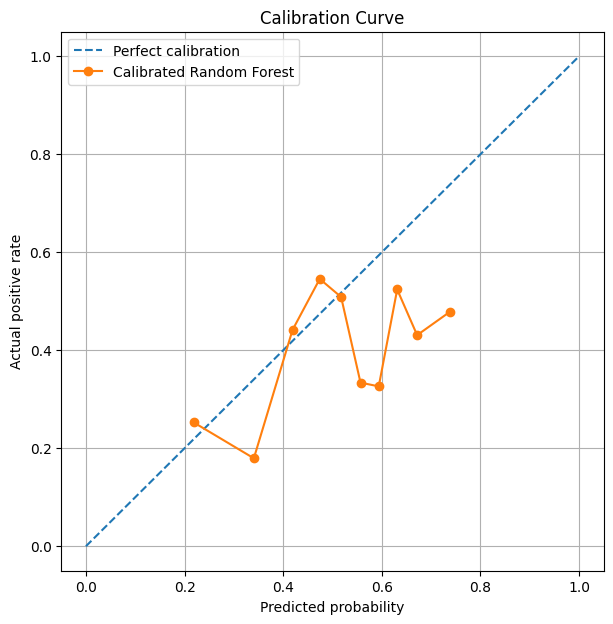

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------

y_true = test_results_calibration["refresh_opportunity"].astype(int)
y_prob = test_results_calibration["refresh_probability"].astype(float)

# ------------------------------------------------------------
# CALIBRATION CURVE
# ------------------------------------------------------------

prob_true, prob_pred = calibration_curve(
    y_true,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

# ------------------------------------------------------------
# CALIBRATION TABLE
# ------------------------------------------------------------

calibration_df = pd.DataFrame({
    "predicted_probability": prob_pred,
    "actual_rate": prob_true
})

calibration_df["difference"] = (
    calibration_df["actual_rate"]
    - calibration_df["predicted_probability"]
)

print("=" * 70)
print("CALIBRATION VALIDATION")
print("=" * 70)

print("\nCalibration table:")
print(calibration_df.to_string(index=False))

print("\nBrier score:")
print(f"{brier_score_loss(y_true, y_prob):.4f}")

print("\nMean predicted probability:")
print(f"{y_prob.mean():.4f}")

print("\nActual positive rate:")
print(f"{y_true.mean():.4f}")

print("\nMean absolute calibration error:")
print(
    f"{calibration_df['difference'].abs().mean():.4f}"
)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Calibrated Random Forest"
)

plt.xlabel("Predicted probability")
plt.ylabel("Actual positive rate")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

In [130]:
# ============================================================
# FEATURE IMPORTANCE VALIDATION
# ============================================================

model_features = [
    "impressions_90d",
    "clicks_90d",
    "avg_position_90d",
    "impressions_last30",
    "clicks_last30",
    "ctr_90d",
    "ctr_last30",
    "content_age_days",
    "days_since_update",
    "search_volume",
    "competition",
    "backlinks",
    "category_count",
    "char_count",
    "word_count",
    "content_type",
    "competition_level",
    "main_intent"
]

print("=" * 70)
print("FEATURE IMPORTANCE VALIDATION")
print("=" * 70)

print("\nNumber of model features:", len(model_features))

# Check that all features exist
missing_features = [
    f for f in model_features
    if f not in test_results_calibration.columns
]

if missing_features:
    print("\nMissing features:")
    print(missing_features)
else:
    print("✅ All model features found")

# Check for forbidden future/target features
forbidden_features = [
    "refresh_opportunity",
    "future_impressions",
    "future_clicks",
    "future_avg_position",
    "impression_change_pct"
]

leakage_features = [
    f for f in model_features
    if f in forbidden_features
]

print("\nLeakage check:")
if leakage_features:
    print("❌ FORBIDDEN FEATURES FOUND:", leakage_features)
else:
    print("✅ No target/future features in model")

# Prepare test data
X_test_eval = test_results_calibration[model_features]
y_test_eval = test_results_calibration["refresh_opportunity"]

print("\nTest shape:", X_test_eval.shape)

# Permutation importance
perm = permutation_importance(
    calibrated_rf,
    X_test_eval,
    y_test_eval,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": model_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

print("\nFEATURE IMPORTANCE:")
print(importance_df.to_string(index=False))

print("\nTOP 10 FEATURES:")
print(importance_df.head(10).to_string(index=False))

FEATURE IMPORTANCE VALIDATION

Number of model features: 18
✅ All model features found

Leakage check:
✅ No target/future features in model

Test shape: (18784, 18)

FEATURE IMPORTANCE:
           feature  importance_mean  importance_std
  avg_position_90d         0.010469        0.000790
 days_since_update         0.008419        0.000351
  content_age_days         0.004406        0.000494
     search_volume         0.003176        0.000568
        char_count         0.002101        0.000481
impressions_last30         0.002031        0.000553
       competition         0.001347        0.000545
     clicks_last30         0.001266        0.000478
 competition_level         0.000949        0.000323
        ctr_last30         0.000817        0.000931
           ctr_90d         0.000742        0.000834
        word_count         0.000565        0.000696
       main_intent         0.000409        0.000157
        clicks_90d         0.000221        0.001565
   impressions_90d         0.00016

In [131]:
print("\nFEATURE IMPORTANCE:")
print(importance_df.to_string(index=False))

print("\nTOP 10 FEATURES:")
print(importance_df.head(10).to_string(index=False))


FEATURE IMPORTANCE:
           feature  importance_mean  importance_std
  avg_position_90d         0.010469        0.000790
 days_since_update         0.008419        0.000351
  content_age_days         0.004406        0.000494
     search_volume         0.003176        0.000568
        char_count         0.002101        0.000481
impressions_last30         0.002031        0.000553
       competition         0.001347        0.000545
     clicks_last30         0.001266        0.000478
 competition_level         0.000949        0.000323
        ctr_last30         0.000817        0.000931
           ctr_90d         0.000742        0.000834
        word_count         0.000565        0.000696
       main_intent         0.000409        0.000157
        clicks_90d         0.000221        0.001565
   impressions_90d         0.000168        0.000671
      content_type         0.000109        0.000041
    category_count         0.000068        0.000399
         backlinks         0.000058        

In [136]:

trend_columns = [
    "impressions_last30",
    "impressions_90d",
    "clicks_last30",
    "clicks_90d",
    "ctr_last30",
    "ctr_90d",
    "avg_position_90d",
    "days_since_update",
    "content_age_days"
]

print("=" * 70)
print("FEATURE ENGINEERING INPUT CHECK")
print("=" * 70)

for col in trend_columns:
    if col in df.columns:
        print(f"✅ {col}")
    else:
        print(f"❌ {col} NOT FOUND")

print("\nCurrent dataframe shape:", df.shape)

print("\nSummary:")
print(
    df[[c for c in trend_columns if c in df.columns]]
    .describe()
    .T
    .to_string()
)

FEATURE ENGINEERING INPUT CHECK
✅ impressions_last30
✅ impressions_90d
✅ clicks_last30
✅ clicks_90d
✅ ctr_last30
✅ ctr_90d
✅ avg_position_90d
✅ days_since_update
✅ content_age_days

Current dataframe shape: (71074, 32)

Summary:
                      count         mean           std        min         25%         50%          75%            max
impressions_last30  71074.0  1125.536750   3883.935572  50.000000  124.000000  298.000000   823.000000  179822.000000
impressions_90d     71074.0  3508.490728  10636.760731  50.000000  370.000000  960.000000  2707.000000  495880.000000
clicks_last30       71074.0     4.243479     18.720368   0.000000    0.000000    0.000000     2.000000    1175.000000
clicks_90d          71074.0    11.140895     50.556238   0.000000    0.000000    2.000000     6.000000    3595.000000
ctr_last30          71074.0     0.003240      0.006002   0.000000    0.000000    0.000000     0.004481       0.245902
ctr_90d             71074.0     0.003020      0.005250   0.0000

In [137]:


import numpy as np

df_fe = df.copy()


df_fe["impression_recent_share"] = (
    df_fe["impressions_last30"] /
    df_fe["impressions_90d"].clip(lower=1)
)


df_fe["click_recent_share"] = (
    df_fe["clicks_last30"] /
    df_fe["clicks_90d"].clip(lower=1)
)


df_fe["ctr_change"] = (
    df_fe["ctr_last30"] -
    df_fe["ctr_90d"]
)


df_fe["ctr_relative_change"] = (
    (df_fe["ctr_last30"] - df_fe["ctr_90d"]) /
    df_fe["ctr_90d"].clip(lower=1e-6)
)


df_fe["update_age_ratio"] = (
    df_fe["days_since_update"] /
    df_fe["content_age_days"].clip(lower=1)
)


df_fe["freshness_gap"] = (
    df_fe["content_age_days"] -
    df_fe["days_since_update"]
)


df_fe["impression_recent_intensity"] = (
    df_fe["impressions_last30"] / 30
)


df_fe["click_recent_intensity"] = (
    df_fe["clicks_last30"] / 30
)


new_features = [
    "impression_recent_share",
    "click_recent_share",
    "ctr_change",
    "ctr_relative_change",
    "update_age_ratio",
    "freshness_gap",
    "impression_recent_intensity",
    "click_recent_intensity"
]

df_fe[new_features] = (
    df_fe[new_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("=" * 70)
print("NEW FEATURES CREATED")
print("=" * 70)

print("\nNew features:")
for feature in new_features:
    print(f"✅ {feature}")

print("\nNew dataframe shape:", df_fe.shape)

print("\nNew feature summary:")
print(
    df_fe[new_features]
    .describe()
    .T
    .to_string()
)

NEW FEATURES CREATED

New features:
✅ impression_recent_share
✅ click_recent_share
✅ ctr_change
✅ ctr_relative_change
✅ update_age_ratio
✅ freshness_gap
✅ impression_recent_intensity
✅ click_recent_intensity

New dataframe shape: (71074, 40)

New feature summary:
                               count        mean         std       min        25%         50%         75%          max
impression_recent_share      71074.0    0.417388    0.271329  0.000623   0.216756    0.334474    0.543210     1.000000
click_recent_share           71074.0    0.278934    0.359065  0.000000   0.000000    0.000000    0.500000     1.000000
ctr_change                   71074.0    0.000220    0.003205 -0.060000  -0.000458    0.000000    0.000437     0.059211
ctr_relative_change          71074.0    0.166935    1.433550 -1.000000  -0.192573    0.000000    0.150308   161.854167
update_age_ratio             71074.0    0.222274    0.206816  0.003937   0.064327    0.146667    0.312500     1.000000
freshness_gap         

In [138]:
base_features = [
    "avg_position_90d",
    "days_since_update",
    "content_age_days",
    "search_volume",
    "char_count",
    "impressions_last30",
    "competition",
    "clicks_last30",
    "competition_level",
    "ctr_last30",
    "ctr_90d",
    "word_count",
    "main_intent",
    "clicks_90d",
    "impressions_90d",
    "content_type",
    "category_count",
    "backlinks"
]

engineered_features = [
    "impression_recent_share",
    "click_recent_share",
    "ctr_change",
    "update_age_ratio",
    "freshness_gap"
]

improved_features = base_features + engineered_features

print("Base features:", len(base_features))
print("Engineered features:", len(engineered_features))
print("Total features:", len(improved_features))

missing = [f for f in improved_features if f not in df_fe.columns]

if missing:
    print("\nMissing features:")
    print(missing)
else:
    print("\nAll features available.")

Base features: 18
Engineered features: 5
Total features: 23

All features available.


In [140]:
print("df columns containing 'label':")
print([c for c in df.columns if "label" in c.lower()])

print("\ndf_fe columns containing 'label':")
print([c for c in df_fe.columns if "label" in c.lower()])

print("\nExisting target variables:")
print("y exists:", "y" in globals())
print("y_improved exists:", "y_improved" in globals())

df columns containing 'label':
[]

df_fe columns containing 'label':
[]

Existing target variables:
y exists: True
y_improved exists: False


In [143]:
print("=" * 70)
print("FEATURE DATA TYPES")
print("=" * 70)

print(X_improved.dtypes)

non_numeric = X_improved.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNon-numeric features:")
print(non_numeric)

print("\nNumeric features:", len(X_improved.select_dtypes(include=[np.number]).columns))
print("Non-numeric features:", len(non_numeric))

if len(X_improved) == len(y_improved):
    print("\nRow alignment: OK")
else:
    print("\nRow alignment: ERROR")

FEATURE DATA TYPES
avg_position_90d           float64
days_since_update            int64
content_age_days             int64
search_volume                Int64
char_count                   Int64
impressions_last30         float64
competition                float64
clicks_last30              float64
competition_level           object
ctr_last30                 float64
ctr_90d                    float64
word_count                   Int64
main_intent                 object
clicks_90d                 float64
impressions_90d            float64
content_type                object
category_count               int64
backlinks                    Int64
impression_recent_share    float64
click_recent_share         float64
ctr_change                 float64
update_age_ratio           float64
freshness_gap                int64
dtype: object

Non-numeric features:
['competition_level', 'main_intent', 'content_type']

Numeric features: 20
Non-numeric features: 3

Row alignment: OK


In [145]:
print("Variables containing model-related names:")

for name in globals():
    if any(x in name.lower() for x in ["model", "rf", "forest", "clf", "classifier", "split", "train", "test"]):
        obj = globals()[name]
        print(f"{name}: {type(obj).__name__}")

Variables containing model-related names:
performance_cols: list
dataset_model: DataFrame
GroupShuffleSplit: ABCMeta
train_idx: ndarray
test_idx: ndarray
X_train: DataFrame
X_test: DataFrame
y_train: Series
y_test: Series
groups_train: Series
groups_test: Series
DummyClassifier: type
RandomForestClassifier: ABCMeta
rf_model: RandomForestClassifier
rf_pred: ndarray
rf_prob: ndarray
classifier: RandomForestClassifier
test_results: DataFrame
test_prob: ndarray
model_precision: float64
client_performance: DataFrame
client_ids_test: Series
test_indices: Index
test_labels: Series
test_results_calibration: DataFrame
CalibratedClassifierCV: type
calibrated_rf: CalibratedClassifierCV
train_content: set
test_content: set
train_content_ids: set
test_content_ids: set
model_features_check: list
model_features: list
X_test_eval: DataFrame
y_test_eval: Series
rf_pruned: RandomForestClassifier
test_df: DataFrame


In [147]:
print("=" * 70)
print("ORIGINAL FEATURE SET")
print("=" * 70)

print("Number of features:", len(model_features))

for i, feature in enumerate(model_features, 1):
    print(i, feature)

print("\nX_train dtypes:")
print(X_train.dtypes)

print("\nX_test dtypes:")
print(X_test.dtypes)

ORIGINAL FEATURE SET
Number of features: 18
1 impressions_90d
2 clicks_90d
3 avg_position_90d
4 impressions_last30
5 clicks_last30
6 ctr_90d
7 ctr_last30
8 content_age_days
9 days_since_update
10 search_volume
11 competition
12 backlinks
13 category_count
14 char_count
15 word_count
16 content_type
17 competition_level
18 main_intent

X_train dtypes:
impressions_90d       float64
clicks_90d            float64
avg_position_90d      float64
impressions_last30    float64
clicks_last30         float64
ctr_90d               float64
ctr_last30            float64
content_age_days        int64
days_since_update       int64
search_volume           Int64
competition           float64
backlinks               Int64
category_count          int64
char_count              Int64
word_count              Int64
content_type           object
competition_level      object
main_intent            object
dtype: object

X_test dtypes:
impressions_90d       float64
clicks_90d            float64
avg_position_90d 

In [149]:
print("=" * 70)
print("SEARCHING FOR PROCESSED TRAINING DATA")
print("=" * 70)

names = list(globals().keys())

for name in names:
    obj = globals().get(name)

    if isinstance(obj, (pd.DataFrame, pd.Series, np.ndarray)):
        try:
            shape = obj.shape
        except:
            continue

        name_lower = name.lower()

        if any(word in name_lower for word in [
            "encoded", "processed", "preprocessed",
            "scaled", "matrix", "train", "test",
            "feature", "input", "x_"
        ]):
            print(f"{name}: {type(obj).__name__}, shape={shape}")

SEARCHING FOR PROCESSED TRAINING DATA
features: DataFrame, shape=(163415, 26)
train_idx: ndarray, shape=(52290,)
test_idx: ndarray, shape=(18784,)
X_train: DataFrame, shape=(52290, 18)
X_test: DataFrame, shape=(18784, 18)
y_train: Series, shape=(52290,)
y_test: Series, shape=(18784,)
groups_train: Series, shape=(52290,)
groups_test: Series, shape=(18784,)
feature_names: ndarray, shape=(27,)
test_results: DataFrame, shape=(18784, 22)
test_prob: ndarray, shape=(18784,)
client_ids_test: Series, shape=(18784,)
test_labels: Series, shape=(18784,)
test_results_calibration: DataFrame, shape=(18784, 23)
feature_importance: DataFrame, shape=(27, 2)
X_test_eval: DataFrame, shape=(18784, 18)
y_test_eval: Series, shape=(18784,)
test_df: DataFrame, shape=(18784, 37)
X_improved: DataFrame, shape=(71074, 23)


In [150]:
print("=" * 70)
print("RANDOM FOREST DETAILS")
print("=" * 70)

print("n_features_in_:", rf_model.n_features_in_)
print("n_estimators:", rf_model.n_estimators)
print("max_depth:", rf_model.max_depth)
print("min_samples_split:", rf_model.min_samples_split)
print("min_samples_leaf:", rf_model.min_samples_leaf)

RANDOM FOREST DETAILS
n_features_in_: 27
n_estimators: 300
max_depth: 12
min_samples_split: 2
min_samples_leaf: 10


In [151]:
print("=" * 70)
print("27 MODEL FEATURES")
print("=" * 70)

print("feature_names length:", len(feature_names))

for i, feature in enumerate(feature_names, 1):
    print(f"{i:2d}. {feature}")

27 MODEL FEATURES
feature_names length: 27
 1. numeric__impressions_90d
 2. numeric__clicks_90d
 3. numeric__avg_position_90d
 4. numeric__impressions_last30
 5. numeric__clicks_last30
 6. numeric__ctr_90d
 7. numeric__ctr_last30
 8. numeric__content_age_days
 9. numeric__days_since_update
10. numeric__search_volume
11. numeric__competition
12. numeric__backlinks
13. numeric__category_count
14. numeric__char_count
15. numeric__word_count
16. categorical__content_type_comparison article
17. categorical__content_type_feedly article
18. categorical__content_type_keyword article
19. categorical__competition_level_HIGH
20. categorical__competition_level_LOW
21. categorical__competition_level_MEDIUM
22. categorical__competition_level_None
23. categorical__main_intent_commercial
24. categorical__main_intent_informational
25. categorical__main_intent_navigational
26. categorical__main_intent_transactional
27. categorical__main_intent_None


In [152]:
print("=" * 70)
print("FINDING PREPROCESSOR")
print("=" * 70)

names = list(globals().keys())

for name in names:
    obj = globals().get(name)

    if obj is None:
        continue

    obj_type = type(obj).__name__

    if obj_type in [
        "ColumnTransformer",
        "Pipeline",
        "OneHotEncoder",
        "StandardScaler"
    ]:
        print(f"{name}: {obj_type}")

FINDING PREPROCESSOR
numeric_transformer: Pipeline
categorical_transformer: Pipeline
preprocessor: ColumnTransformer
pipeline: Pipeline


In [153]:
print("=" * 70)
print("PREPROCESSOR STRUCTURE")
print("=" * 70)

print(preprocessor)

PREPROCESSOR STRUCTURE
ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['impressions_90d', 'clicks_90d',
                                  'avg_position_90d', 'impressions_last30',
                                  'clicks_last30', 'ctr_90d', 'ctr_last30',
                                  'content_age_days', 'days_since_update',
                                  'search_volume', 'competition', 'backlinks',
                                  'category_count', 'char_count',
                                  'word_count']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
              

In [154]:
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

numeric_features_improved = [
    "impressions_90d",
    "clicks_90d",
    "avg_position_90d",
    "impressions_last30",
    "clicks_last30",
    "ctr_90d",
    "ctr_last30",
    "content_age_days",
    "days_since_update",
    "search_volume",
    "competition",
    "backlinks",
    "category_count",
    "char_count",
    "word_count",
    "impression_recent_share",
    "click_recent_share",
    "ctr_change",
    "update_age_ratio",
    "freshness_gap"
]

categorical_features = [
    "content_type",
    "competition_level",
    "main_intent"
]

numeric_transformer_improved = clone(
    preprocessor.named_transformers_["numeric"]
)

categorical_transformer_improved = clone(
    preprocessor.named_transformers_["categorical"]
)

preprocessor_improved = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer_improved,
            numeric_features_improved
        ),
        (
            "categorical",
            categorical_transformer_improved,
            categorical_features
        )
    ]
)

X_train_raw_improved = df_fe.iloc[train_idx][
    numeric_features_improved + categorical_features
]

X_test_raw_improved = df_fe.iloc[test_idx][
    numeric_features_improved + categorical_features
]

X_train_processed_improved = preprocessor_improved.fit_transform(
    X_train_raw_improved
)

X_test_processed_improved = preprocessor_improved.transform(
    X_test_raw_improved
)

print("=" * 70)
print("IMPROVED PREPROCESSING")
print("=" * 70)

print("Training rows:", X_train_processed_improved.shape[0])
print("Test rows:", X_test_processed_improved.shape[0])
print("Model features:", X_train_processed_improved.shape[1])

print("\nExpected:")
print("Training rows: 52290")
print("Test rows: 18784")
print("Expected model features: 32")

IMPROVED PREPROCESSING
Training rows: 52290
Test rows: 18784
Model features: 32

Expected:
Training rows: 52290
Test rows: 18784
Expected model features: 32


In [155]:
from sklearn.ensemble import RandomForestClassifier

rf_improved = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=2,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_improved.fit(
    X_train_processed_improved,
    y_train
)

print("=" * 70)
print("IMPROVED RANDOM FOREST TRAINING")
print("=" * 70)

print("Training complete")
print("Training rows:", X_train_processed_improved.shape[0])
print("Test rows:", X_test_processed_improved.shape[0])
print("Features:", X_train_processed_improved.shape[1])
print("Trees:", rf_improved.n_estimators)
print("Max depth:", rf_improved.max_depth)
print("Min samples leaf:", rf_improved.min_samples_leaf)

IMPROVED RANDOM FOREST TRAINING
Training complete
Training rows: 52290
Test rows: 18784
Features: 32
Trees: 300
Max depth: 12
Min samples leaf: 10


In [156]:
from sklearn.metrics import roc_auc_score, average_precision_score

improved_prob = rf_improved.predict_proba(
    X_test_processed_improved
)[:, 1]

improved_roc_auc = roc_auc_score(
    y_test,
    improved_prob
)

improved_pr_auc = average_precision_score(
    y_test,
    improved_prob
)

baseline_roc_auc = 0.5706
baseline_pr_auc = 0.4540

print("=" * 70)
print("BASELINE vs IMPROVED MODEL")
print("=" * 70)

print(f"\nBaseline ROC-AUC : {baseline_roc_auc:.4f}")
print(f"Improved ROC-AUC : {improved_roc_auc:.4f}")
print(f"Change           : {improved_roc_auc - baseline_roc_auc:+.4f}")

print(f"\nBaseline PR-AUC  : {baseline_pr_auc:.4f}")
print(f"Improved PR-AUC  : {improved_pr_auc:.4f}")
print(f"Change           : {improved_pr_auc - baseline_pr_auc:+.4f}")

print("\n" + "=" * 70)

if improved_pr_auc > baseline_pr_auc:
    print("✅ PR-AUC improved")
elif improved_pr_auc < baseline_pr_auc:
    print("❌ PR-AUC decreased")
else:
    print("➡️ PR-AUC unchanged")

BASELINE vs IMPROVED MODEL

Baseline ROC-AUC : 0.5706
Improved ROC-AUC : 0.6655
Change           : +0.0949

Baseline PR-AUC  : 0.4540
Improved PR-AUC  : 0.5235
Change           : +0.0695

✅ PR-AUC improved


In [157]:
print("=" * 70)
print("BASELINE CALIBRATION OBJECT")
print("=" * 70)

print(type(calibrated_rf).__name__)

print("\nCalibration parameters:")
print(calibrated_rf.get_params())

BASELINE CALIBRATION OBJECT
CalibratedClassifierCV

Calibration parameters:
{'cv': 3, 'ensemble': 'auto', 'estimator__memory': None, 'estimator__steps': [('preprocessor', ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['impressions_90d', 'clicks_90d',
                                  'avg_position_90d', 'impressions_last30',
                                  'clicks_last30', 'ctr_90d', 'ctr_last30',
                                  'content_age_days', 'days_since_update',
                                  'search_volume', 'competition', 'backlinks',
                                  'category_count', 'char_count',
                                  'word_count']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                       

In [158]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_rf_improved = CalibratedClassifierCV(
    estimator=rf_improved,
    method="sigmoid",
    cv=3,
    n_jobs=-1
)

calibrated_rf_improved.fit(
    X_train_processed_improved,
    y_train
)

improved_calibrated_prob = calibrated_rf_improved.predict_proba(
    X_test_processed_improved
)[:, 1]

print("=" * 70)
print("IMPROVED MODEL CALIBRATION")
print("=" * 70)

print("Calibration complete")
print("Method: sigmoid")
print("CV folds: 3")
print("Test probabilities:", len(improved_calibrated_prob))
print(
    "Probability range:",
    round(improved_calibrated_prob.min(), 6),
    "to",
    round(improved_calibrated_prob.max(), 6)
)

IMPROVED MODEL CALIBRATION
Calibration complete
Method: sigmoid
CV folds: 3
Test probabilities: 18784
Probability range: 0.104585 to 0.789979


In [159]:
print("=" * 70)
print("THRESHOLD-RELATED VARIABLES")
print("=" * 70)

names = list(globals().keys())

for name in names:
    if "threshold" in name.lower():
        obj = globals().get(name)
        print(f"{name}: {type(obj).__name__}")

print("\nRelevant metric variables:")

for name in names:
    if any(x in name.lower() for x in [
        "precision", "recall", "f1", "f2", "average_precision"
    ]):
        obj = globals().get(name)
        if isinstance(obj, (float, int, np.number, pd.DataFrame, pd.Series)):
            try:
                print(f"{name}: {type(obj).__name__}, shape={obj.shape}")
            except:
                print(f"{name}: {obj}")

THRESHOLD-RELATED VARIABLES
threshold_check: DataFrame
thresholds: list
threshold_report: DataFrame
threshold_results: list
threshold: float
threshold_results_df: DataFrame
threshold_business: list
threshold_business_df: DataFrame
threshold_results_calibrated: DataFrame
final_threshold_comparison: DataFrame
decline_thresholds: list
future_imp_thresholds: list
FINAL_THRESHOLD: float

Relevant metric variables:
precision: float64, shape=()
model_precision: float64, shape=()
recall: float64, shape=()
f1: 0.20466825156689
precision_k: float64, shape=()
orig_precision: float64, shape=()
orig_recall: float64, shape=()
cal_precision: float64, shape=()
cal_recall: float64, shape=()


In [160]:
print("=" * 70)
print("BASELINE THRESHOLD SELECTION")
print("=" * 70)

print("FINAL_THRESHOLD:", FINAL_THRESHOLD)
print("threshold:", threshold)

print("\nThreshold report:")
print(threshold_report.to_string(index=False))

print("\nCalibrated threshold results:")
print(threshold_results_calibrated.to_string(index=False))

print("\nFinal threshold comparison:")
print(final_threshold_comparison.to_string(index=False))

BASELINE THRESHOLD SELECTION
FINAL_THRESHOLD: 0.6
threshold: 0.6

Threshold report:
 min_last30_impressions decline_threshold  eligible_pages  declined_pages  decline_rate_percent
                     10               30%           92164           56526                 61.33
                     10               40%           92164           50109                 54.37
                     10               50%           92164           42579                 46.20
                     10               60%           92164           33933                 36.82
                     20               30%           84720           51470                 60.75
                     20               40%           84720           45421                 53.61
                     20               50%           84720           38316                 45.23
                     20               60%           84720           30211                 35.66
                     50               30%           

In [161]:
from sklearn.metrics import precision_score, recall_score

candidate_thresholds = [0.50, 0.55, 0.60]

improved_threshold_results = []

total_test_pages = len(y_test)
total_actual_declines = int(y_test.sum())

for t in candidate_thresholds:
    predictions = (improved_calibrated_prob >= t).astype(int)

    recommendations = int(predictions.sum())
    actual_declines_captured = int(
        ((predictions == 1) & (y_test.to_numpy() == 1)).sum()
    )

    precision_value = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall_value = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    recommendation_pct = (
        recommendations / total_test_pages * 100
    )

    pages_avoided = total_test_pages - recommendations

    baseline_decline_rate = total_actual_declines / total_test_pages

    lift = (
        precision_value / baseline_decline_rate
        if baseline_decline_rate > 0
        else 0
    )

    improved_threshold_results.append({
        "threshold": t,
        "recommendations": recommendations,
        "recommendation_pct": recommendation_pct,
        "actual_declines_captured": actual_declines_captured,
        "precision": precision_value,
        "recall": recall_value,
        "pages_avoided": pages_avoided,
        "lift": lift
    })

improved_threshold_results_df = pd.DataFrame(
    improved_threshold_results
)

print("=" * 70)
print("IMPROVED MODEL — THRESHOLD COMPARISON")
print("=" * 70)

print(
    improved_threshold_results_df.to_string(
        index=False,
        formatters={
            "recommendation_pct": "{:.2f}".format,
            "precision": "{:.4f}".format,
            "recall": "{:.4f}".format,
            "lift": "{:.4f}".format
        }
    )
)

IMPROVED MODEL — THRESHOLD COMPARISON
 threshold  recommendations recommendation_pct  actual_declines_captured precision recall  pages_avoided   lift
      0.50             7327              39.01                      3943    0.5381 0.5220          11457 1.3382
      0.55             4811              25.61                      2740    0.5695 0.3627          13973 1.4162
      0.60             2458              13.09                      1457    0.5928 0.1929          16326 1.4740


In [162]:
FINAL_THRESHOLD_IMPROVED = 0.60

final_improved_pred = (
    improved_calibrated_prob >= FINAL_THRESHOLD_IMPROVED
).astype(int)

final_improved_precision = precision_score(
    y_test,
    final_improved_pred,
    zero_division=0
)

final_improved_recall = recall_score(
    y_test,
    final_improved_pred,
    zero_division=0
)

final_improved_f1 = f1_score(
    y_test,
    final_improved_pred,
    zero_division=0
)

final_improved_recommendations = int(
    final_improved_pred.sum()
)

final_improved_declines = int(
    ((final_improved_pred == 1) & (y_test.to_numpy() == 1)).sum()
)

final_improved_pages_avoided = (
    len(y_test) - final_improved_recommendations
)

baseline_decline_rate = y_test.mean()

final_improved_lift = (
    final_improved_precision / baseline_decline_rate
)

print("=" * 70)
print("FINAL IMPROVED MODEL — THRESHOLD 0.60")
print("=" * 70)

print(f"Threshold:              {FINAL_THRESHOLD_IMPROVED:.2f}")
print(f"Recommendations:        {final_improved_recommendations:,}")
print(f"Actual declines:        {final_improved_declines:,}")
print(f"Precision:              {final_improved_precision:.4f}")
print(f"Recall:                 {final_improved_recall:.4f}")
print(f"F1:                     {final_improved_f1:.4f}")
print(f"Recommendation rate:    {final_improved_recommendations / len(y_test):.2%}")
print(f"Pages avoided:          {final_improved_pages_avoided:,}")
print(f"Lift:                   {final_improved_lift:.4f}x")

FINAL IMPROVED MODEL — THRESHOLD 0.60
Threshold:              0.60
Recommendations:        2,458
Actual declines:        1,457
Precision:              0.5928
Recall:                 0.1929
F1:                     0.2911
Recommendation rate:    13.09%
Pages avoided:          16,326
Lift:                   1.4740x


In [163]:
comparison = pd.DataFrame([
    {
        "model": "Baseline RF",
        "features": 27,
        "roc_auc": 0.5706,
        "pr_auc": 0.4540,
        "threshold": 0.60,
        "recommendations": 3051,
        "precision": 0.571288,
        "recall": 0.230739,
        "f1": None,
        "pages_avoided": 15733,
        "lift": 1.420582
    },
    {
        "model": "Improved RF",
        "features": 32,
        "roc_auc": improved_roc_auc,
        "pr_auc": improved_pr_auc,
        "threshold": FINAL_THRESHOLD_IMPROVED,
        "recommendations": final_improved_recommendations,
        "precision": final_improved_precision,
        "recall": final_improved_recall,
        "f1": final_improved_f1,
        "pages_avoided": final_improved_pages_avoided,
        "lift": final_improved_lift
    }
])

print("=" * 70)
print("FINAL BASELINE vs IMPROVED MODEL")
print("=" * 70)

print(
    comparison.to_string(
        index=False,
        formatters={
            "roc_auc": "{:.4f}".format,
            "pr_auc": "{:.4f}".format,
            "threshold": "{:.2f}".format,
            "precision": "{:.4f}".format,
            "recall": "{:.4f}".format,
            "f1": lambda x: "N/A" if pd.isna(x) else f"{x:.4f}",
            "lift": "{:.4f}".format
        }
    )
)

FINAL BASELINE vs IMPROVED MODEL
      model  features roc_auc pr_auc threshold  recommendations precision recall     f1  pages_avoided   lift
Baseline RF        27  0.5706 0.4540      0.60             3051    0.5713 0.2307    NaN          15733 1.4206
Improved RF        32  0.6655 0.5235      0.60             2458    0.5928 0.1929 0.2911          16326 1.4740


In [164]:
print("=" * 70)
print("FINAL IMPROVED MODEL SANITY CHECKS")
print("=" * 70)

print("\n1. Prediction length")
print("Expected:", len(y_test))
print("Actual:", len(improved_calibrated_prob))
print("Status:", "OK" if len(y_test) == len(improved_calibrated_prob) else "ERROR")

print("\n2. Probability NaN check")
print("NaN:", np.isnan(improved_calibrated_prob).sum())
print("Status:", "OK" if not np.isnan(improved_calibrated_prob).any() else "ERROR")

print("\n3. Probability range")
print("Min:", improved_calibrated_prob.min())
print("Max:", improved_calibrated_prob.max())
print(
    "Status:",
    "OK" if (
        np.all(improved_calibrated_prob >= 0) and
        np.all(improved_calibrated_prob <= 1)
    )
    else "ERROR"
)

print("\n4. Final threshold")
print("Threshold:", FINAL_THRESHOLD_IMPROVED)

print("\n5. Recommendation count")
print("Recommendations:", final_improved_recommendations)
print("Recommendation rate:", f"{final_improved_recommendations / len(y_test):.2%}")

print("\n6. Actual declines captured")
print("Captured:", final_improved_declines)

print("\n7. Precision")
print("Precision:", f"{final_improved_precision:.4f}")

print("\n8. Recall")
print("Recall:", f"{final_improved_recall:.4f}")

print("\n9. F1")
print("F1:", f"{final_improved_f1:.4f}")

print("\n10. Lift")
print("Lift:", f"{final_improved_lift:.4f}x")

print("\n" + "=" * 70)

all_checks_pass = (
    len(y_test) == len(improved_calibrated_prob)
    and not np.isnan(improved_calibrated_prob).any()
    and np.all(improved_calibrated_prob >= 0)
    and np.all(improved_calibrated_prob <= 1)
    and final_improved_recommendations > 0
)

print(
    "FINAL STATUS:",
    "ALL SANITY CHECKS PASSED"
    if all_checks_pass
    else " CHECK FAILED"
)

FINAL IMPROVED MODEL SANITY CHECKS

1. Prediction length
Expected: 18784
Actual: 18784
Status: OK

2. Probability NaN check
NaN: 0
Status: OK

3. Probability range
Min: 0.10458460243856543
Max: 0.7899792401549283
Status: OK

4. Final threshold
Threshold: 0.6

5. Recommendation count
Recommendations: 2458
Recommendation rate: 13.09%

6. Actual declines captured
Captured: 1457

7. Precision
Precision: 0.5928

8. Recall
Recall: 0.1929

9. F1
F1: 0.2911

10. Lift
Lift: 1.4740x

FINAL STATUS: ALL SANITY CHECKS PASSED


In [165]:
print("=" * 70)
print("FINAL RECOMMENDATION DATASET")
print("=" * 70)

print("test_df shape:", test_df.shape)

print("\nColumns:")
for i, col in enumerate(test_df.columns, 1):
    print(f"{i:2d}. {col}")

FINAL RECOMMENDATION DATASET
test_df shape: (18784, 37)

Columns:
 1. client_hash_id
 2. content_hash_id
 3. snapshot_date
 4. impressions_90d
 5. clicks_90d
 6. avg_position_90d
 7. impressions_last30
 8. clicks_last30
 9. content_created_date
10. content_updated_date
11. last_optimized_date
12. content_type
13. search_volume
14. competition
15. competition_level
16. main_intent
17. backlinks
18. category_count
19. char_count
20. word_count
21. is_published
22. is_deleted
23. ctr_90d
24. ctr_last30
25. content_age_days
26. days_since_update
27. future_impressions
28. future_clicks
29. future_avg_position
30. has_future_data
31. refresh_opportunity
32. impression_change_pct
33. has_position_data
34. STALE
35. LOW_CTR
36. STRIKING
37. rule_score


In [166]:
final_recommendations = test_df.copy()

final_recommendations["decline_probability"] = improved_calibrated_prob
final_recommendations["recommendation"] = np.where(
    improved_calibrated_prob >= FINAL_THRESHOLD_IMPROVED,
    "REFRESH",
    "NO_ACTION"
)

final_recommendations["recommendation_threshold"] = FINAL_THRESHOLD_IMPROVED

final_recommendations["recommendation_rank"] = (
    final_recommendations["decline_probability"]
    .rank(method="first", ascending=False)
    .astype(int)
)

export_columns = [
    "client_hash_id",
    "content_hash_id",
    "snapshot_date",
    "decline_probability",
    "recommendation",
    "recommendation_threshold",
    "recommendation_rank",
    "impressions_90d",
    "clicks_90d",
    "avg_position_90d",
    "impressions_last30",
    "clicks_last30",
    "ctr_90d",
    "ctr_last30",
    "content_age_days",
    "days_since_update",
    "content_updated_date",
    "last_optimized_date",
    "content_type",
    "search_volume",
    "competition",
    "competition_level",
    "main_intent",
    "backlinks",
    "category_count",
    "char_count",
    "word_count",
    "is_published",
    "is_deleted",
    "refresh_opportunity",
    "impression_change_pct",
    "STALE",
    "LOW_CTR",
    "STRIKING",
    "rule_score"
]

final_recommendations = final_recommendations[export_columns]

final_recommendations = final_recommendations.sort_values(
    "decline_probability",
    ascending=False
).reset_index(drop=True)

output_path = "/content/final_content_refresh_recommendations.csv"

final_recommendations.to_csv(
    output_path,
    index=False
)

print("=" * 70)
print("FINAL RECOMMENDATIONS EXPORT")
print("=" * 70)

print("Shape:", final_recommendations.shape)
print("File:", output_path)

print("\nRecommendation counts:")
print(final_recommendations["recommendation"].value_counts())

print("\nTop 10 recommendations:")
print(
    final_recommendations[
        [
            "content_hash_id",
            "decline_probability",
            "recommendation",
            "recommendation_rank"
        ]
    ].head(10).to_string(index=False)
)

print("\nFuture-information columns included:")

future_columns = [
    "future_impressions",
    "future_clicks",
    "future_avg_position",
    "has_future_data"
]

print(
    "None"
    if not any(col in final_recommendations.columns for col in future_columns)
    else [
        col for col in future_columns
        if col in final_recommendations.columns
    ]
)

FINAL RECOMMENDATIONS EXPORT
Shape: (18784, 35)
File: /content/final_content_refresh_recommendations.csv

Recommendation counts:
recommendation
NO_ACTION    16326
REFRESH       2458
Name: count, dtype: int64

Top 10 recommendations:
         content_hash_id  decline_probability recommendation  recommendation_rank
content_5def95fb242acd16             0.789979        REFRESH                    1
content_dd10b20ed3f50db6             0.780264        REFRESH                    2
content_40c1eb0eb31c78bd             0.775712        REFRESH                    3
content_43651fbf6627507b             0.774105        REFRESH                    4
content_3aa2b6f4f9a75d76             0.773559        REFRESH                    5
content_dbb1f8bd087c7003             0.767190        REFRESH                    6
content_4731d874b1b59bda             0.763739        REFRESH                    7
content_31fa00ff04977de4             0.763113        REFRESH                    8
content_42fe2f5719244f81     

In [167]:
print("=" * 70)
print("IMPROVED MODEL ARTIFACTS")
print("=" * 70)

for name in sorted(globals()):
    name_lower = name.lower()

    if any(x in name_lower for x in [
        "improved",
        "preprocess",
        "feature_names",
        "rf_"
    ]):
        obj = globals()[name]

        try:
            print(
                f"{name}: "
                f"{type(obj).__name__}, "
                f"shape={obj.shape}"
            )
        except:
            print(
                f"{name}: "
                f"{type(obj).__name__}"
            )

IMPROVED MODEL ARTIFACTS
FINAL_THRESHOLD_IMPROVED: float
X_improved: DataFrame, shape=(71074, 23)
X_test_processed_improved: ndarray, shape=(18784, 32)
X_test_raw_improved: DataFrame, shape=(18784, 23)
X_train_processed_improved: ndarray, shape=(52290, 32)
X_train_raw_improved: DataFrame, shape=(52290, 23)
calibrated_rf_improved: CalibratedClassifierCV
categorical_transformer_improved: Pipeline
feature_names: ndarray, shape=(27,)
final_improved_declines: int
final_improved_f1: float
final_improved_lift: float64, shape=()
final_improved_pages_avoided: int
final_improved_precision: float
final_improved_pred: ndarray, shape=(18784,)
final_improved_recall: float
final_improved_recommendations: int
improved_calibrated_prob: ndarray, shape=(18784,)
improved_features: list
improved_pr_auc: float64, shape=()
improved_prob: ndarray, shape=(18784,)
improved_roc_auc: float64, shape=()
improved_threshold_results: list
improved_threshold_results_df: DataFrame, shape=(3, 8)
numeric_features_improved

In [168]:
import os
import joblib
import json
import pandas as pd

model_dir = "/content/final_content_refresh_model"

os.makedirs(model_dir, exist_ok=True)

joblib.dump(
    calibrated_rf_improved,
    os.path.join(model_dir, "calibrated_improved_rf.pkl")
)

joblib.dump(
    preprocessor_improved,
    os.path.join(model_dir, "preprocessor_improved.pkl")
)

joblib.dump(
    rf_improved,
    os.path.join(model_dir, "rf_improved.pkl")
)

joblib.dump(
    improved_features,
    os.path.join(model_dir, "feature_list.pkl")
)

metadata = {
    "model_type": "RandomForestClassifier",
    "calibration": "sigmoid",
    "calibration_cv": 3,
    "raw_feature_count": len(improved_features),
    "processed_feature_count": X_train_processed_improved.shape[1],
    "training_rows": X_train_processed_improved.shape[0],
    "test_rows": X_test_processed_improved.shape[0],
    "roc_auc": float(improved_roc_auc),
    "pr_auc": float(improved_pr_auc),
    "final_threshold": float(FINAL_THRESHOLD_IMPROVED),
    "recommendations": int(final_improved_recommendations),
    "recommendation_rate": float(
        final_improved_recommendations / len(y_test)
    ),
    "precision": float(final_improved_precision),
    "recall": float(final_improved_recall),
    "f1": float(final_improved_f1),
    "lift": float(final_improved_lift),
    "pages_avoided": int(final_improved_pages_avoided),
    "actual_declines_captured": int(final_improved_declines)
}

with open(
    os.path.join(model_dir, "model_metadata.json"),
    "w"
) as f:
    json.dump(metadata, f, indent=4)

print("=" * 70)
print("FINAL MODEL PACKAGE SAVED")
print("=" * 70)

for filename in sorted(os.listdir(model_dir)):
    filepath = os.path.join(model_dir, filename)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"{filename:40s} {size_kb:,.1f} KB")

print("\nModel directory:")
print(model_dir)

FINAL MODEL PACKAGE SAVED
calibrated_improved_rf.pkl               121,434.9 KB
feature_list.pkl                         0.4 KB
model_metadata.json                      0.6 KB
preprocessor_improved.pkl                4.6 KB
rf_improved.pkl                          34,947.7 KB

Model directory:
/content/final_content_refresh_model


In [170]:
import os
import joblib
import numpy as np

model_dir = "/content/final_content_refresh_model"

loaded_model = joblib.load(
    os.path.join(model_dir, "calibrated_improved_rf.pkl")
)

loaded_prob = loaded_model.predict_proba(
    X_test_processed_improved
)[:, 1]

prob_difference = np.abs(
    loaded_prob - improved_calibrated_prob
)

loaded_pred = (
    loaded_prob >= FINAL_THRESHOLD_IMPROVED
).astype(int)

prediction_match = np.array_equal(
    loaded_pred,
    final_improved_pred
)

print("=" * 70)
print("SAVED MODEL VERIFICATION")
print("=" * 70)

print("Loaded model:", type(loaded_model).__name__)

print("\nProbability count:")
print("Expected:", len(improved_calibrated_prob))
print("Loaded:", len(loaded_prob))

print("\nMaximum probability difference:")
print(f"{prob_difference.max():.12f}")

print("\nMean probability difference:")
print(f"{prob_difference.mean():.12f}")

print("\nPredictions identical:")
print(prediction_match)

print("\nLoaded recommendation count:")
print(loaded_pred.sum())

print("\nExpected recommendation count:")
print(final_improved_recommendations)

print("\nThreshold:")
print(FINAL_THRESHOLD_IMPROVED)

verification_passed = (
    len(loaded_prob) == len(improved_calibrated_prob)
    and prob_difference.max() < 1e-10
    and prediction_match
    and loaded_pred.sum() == final_improved_recommendations
)

print("\n" + "=" * 70)

if verification_passed:
    print("FINAL STATUS:  SAVED MODEL VERIFIED")
else:
    print("FINAL STATUS:  VERIFICATION FAILED")

SAVED MODEL VERIFICATION
Loaded model: CalibratedClassifierCV

Probability count:
Expected: 18784
Loaded: 18784

Maximum probability difference:
0.000000000000

Mean probability difference:
0.000000000000

Predictions identical:
True

Loaded recommendation count:
2458

Expected recommendation count:
2458

Threshold:
0.6

FINAL STATUS:  SAVED MODEL VERIFIED


In [171]:
print("=" * 70)
print("FINAL FEATURE ENGINEERING RESULTS")
print("=" * 70)

print("\nOriginal features:")
for i, feature in enumerate(model_features, 1):
    print(f"{i:2d}. {feature}")

print("\nImproved raw features:")
for i, feature in enumerate(improved_features, 1):
    print(f"{i:2d}. {feature}")

print("\nEngineered features:")
engineered_features = [
    feature for feature in improved_features
    if feature not in model_features
]

for i, feature in enumerate(engineered_features, 1):
    print(f"{i:2d}. {feature}")

print("\nFeature counts:")
print("Original raw features:", len(model_features))
print("Improved raw features:", len(improved_features))
print("Engineered features:", len(engineered_features))
print("Original encoded features:", 27)
print("Improved encoded features:", X_train_processed_improved.shape[1])

print("\nModel performance:")
print(f"Baseline ROC-AUC: {0.5706:.4f}")
print(f"Improved ROC-AUC: {float(improved_roc_auc):.4f}")
print(f"ROC-AUC improvement: {float(improved_roc_auc) - 0.5706:+.4f}")

print(f"\nBaseline PR-AUC: {0.4540:.4f}")
print(f"Improved PR-AUC: {float(improved_pr_auc):.4f}")
print(f"PR-AUC improvement: {float(improved_pr_auc) - 0.4540:+.4f}")

print("\nFinal business metrics:")
print(f"Threshold: {FINAL_THRESHOLD_IMPROVED:.2f}")
print(f"Precision: {final_improved_precision:.4f}")
print(f"Recall: {final_improved_recall:.4f}")
print(f"F1: {final_improved_f1:.4f}")
print(f"Lift: {final_improved_lift:.4f}x")
print(f"Recommendations: {final_improved_recommendations:,}")
print(f"Pages avoided: {final_improved_pages_avoided:,}")

FINAL FEATURE ENGINEERING RESULTS

Original features:
 1. impressions_90d
 2. clicks_90d
 3. avg_position_90d
 4. impressions_last30
 5. clicks_last30
 6. ctr_90d
 7. ctr_last30
 8. content_age_days
 9. days_since_update
10. search_volume
11. competition
12. backlinks
13. category_count
14. char_count
15. word_count
16. content_type
17. competition_level
18. main_intent

Improved raw features:
 1. avg_position_90d
 2. days_since_update
 3. content_age_days
 4. search_volume
 5. char_count
 6. impressions_last30
 7. competition
 8. clicks_last30
 9. competition_level
10. ctr_last30
11. ctr_90d
12. word_count
13. main_intent
14. clicks_90d
15. impressions_90d
16. content_type
17. category_count
18. backlinks
19. impression_recent_share
20. click_recent_share
21. ctr_change
22. update_age_ratio
23. freshness_gap

Engineered features:
 1. impression_recent_share
 2. click_recent_share
 3. ctr_change
 4. update_age_ratio
 5. freshness_gap

Feature counts:
Original raw features: 18
Improved 

## 1. Question

*The research question and the decision it supports.*

1.1 Research Question

The central research question of this capstone project is:

Can historical content-performance, content freshness, search demand, competition, and content characteristics be used to predict which content pages are more likely to experience future performance decline?

The motivation for this question is that a large content inventory can contain many pages with different levels of performance, freshness, search demand, and competitive pressure. Manually evaluating every page for a possible refresh can be inefficient. A predictive model can potentially help narrow the inventory into a smaller group of pages that deserves closer human review.

The project therefore investigates whether historical information available before the future observation period contains enough predictive signal to distinguish relatively higher-risk pages from lower-risk pages.

The objective is not to prove that a particular factor causes content decline. Instead, the objective is to determine whether these observable historical characteristics can provide useful predictive information for prioritization.

1.2 Decision Supported

The practical decision supported by the model is:

Which content pages should be reviewed first for a potential content refresh?

The model produces a probability representing the estimated likelihood of the defined future decline outcome.

Pages can then be ranked according to this probability.

The final operating threshold was selected as:

0.60

Pages with calibrated predicted probability of at least 0.60 were classified as:

REFRESH

Pages below the threshold were classified as:

NO_ACTION

On the held-out test set of 18,784 pages, the final improved model produced:

2,458 REFRESH recommendations
16,326 NO_ACTION recommendations
13.09% recommendation rate
59.28% precision
19.29% recall
0.2911 F1
1.474× lift

Therefore, the model is best interpreted as a prioritization and decision-support system.

It does not automatically decide that a page must be refreshed. Instead, it identifies a smaller set of pages for content-team review.

1.3 Why This Decision Matters

Without prioritization, a content team may need to evaluate a large number of pages manually.

The model changes the workflow from:

Review everything → decide what to refresh

to:

Score the content inventory → rank potential opportunities → review highest-priority pages → decide what action to take.

This can make the content-refresh process more systematic and data-driven.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Dataset and Release

The project uses an anonymized content-performance dataset prepared for the capstone.

The final modeling dataset contained:

71,074 observations

The dataset contains anonymized identifiers such as:

client_hash_id
content_hash_id

No client names are required for the public-facing analysis.

Data Used

The original modeling features covered:

Historical performance
impressions_90d
clicks_90d
avg_position_90d
impressions_last30
clicks_last30
ctr_90d
ctr_last30
Content and freshness
content_age_days
days_since_update
category_count
char_count
word_count
content_type
Search and competition
search_volume
competition
competition_level
main_intent
Authority
backlinks

This produced 18 original raw features and 27 encoded model features after preprocessing.

Date Windows

The analysis primarily uses:

90-day historical performance windows
30-day recent-performance windows

The 90-day measurements provide a longer-term reference, while the 30-day measurements capture more recent behavior.

Feature Engineering Windows

Five additional historical/trend features were created:

impression_recent_share
click_recent_share
ctr_change
update_age_ratio
freshness_gap

These increased the raw feature count from 18 to 23, producing 32 encoded model features.

Excluded Information

Future outcome variables were excluded from the model inputs, including:

future_impressions
future_clicks
future_avg_position
has_future_data

These variables describe information from the future outcome period.

They were excluded to prevent target leakage and ensure that predictions are based on information available before the outcome period.

The final recommendation export was also checked and contained:

No future-information columns.

Public-Safe Scope

The public paper should contain:

anonymized IDs
aggregated metrics
model results
charts
methodology
recommendations

It should not contain:

client names
private URLs
private search queries
other directly identifying client information

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Assumptions

The project assumes that historical content behavior contains useful signals about future performance decline.

It also assumes that:

recent performance can provide early-warning information;
freshness can influence future performance;
search demand and competition provide useful context;
historical relationships can provide useful prioritization signals.

These are modeling assumptions rather than causal claims.

Target / Label

The target variable represents whether a content item met the project's predefined future-decline condition.

The label was derived from future performance information.

However, the model's predictive features were restricted to information available before that future period.

The modeling data had a positive-class rate of:

43.05%

Baseline

The baseline was a Random Forest Classifier.

Parameters:

n_estimators = 300
max_depth = 12
min_samples_leaf = 10
class_weight = balanced
random_state = 42

The baseline used the original 18 raw features.

After preprocessing:

27 model features

Improved Model

The improved model added five historical/trend features:

impression_recent_share
click_recent_share
ctr_change
update_age_ratio
freshness_gap

The improved model therefore used:

23 raw features → 32 encoded features

The model architecture remained a Random Forest. The improvement came from adding better historical/trend representations rather than changing to a completely different model family.

Validation Design

The dataset was divided into:

Dataset	Rows
Total	71,074
Training	52,290
Test	18,784

The same held-out test set was used for baseline and improved-model comparison.

This makes the performance comparison directly comparable.

Leakage Checks

The workflow included:

target validation;
target/future-feature leakage checks;
train/test content-overlap checks;
feature availability checks;
training/test row-alignment checks;
final prediction-length checks;
probability NaN checks;
probability-range checks;
saved-model verification.

The final sanity checks passed.

Calibration

The Random Forest probabilities were calibrated using:

Sigmoid calibration with 3-fold cross-validation

The calibrated probabilities were then used for threshold selection.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Both models were evaluated on the same held-out test set of 18,784 observations.

Honest Comparison
Metric	Baseline RF	Improved RF	Change
Raw features	18	23	+5
Encoded features	27	32	+5
ROC-AUC	0.5706	0.6655	+0.0949
PR-AUC	0.4540	0.5235	+0.0695
Threshold	0.60	0.60	—
Precision	57.13%	59.28%	+2.15 pp
Recall	23.07%	19.29%	−3.78 pp
F1	—	0.2911	—
Recommendations	3,051	2,458	−593
Pages avoided	15,733	16,326	+593
Lift	1.4206×	1.4740×	+0.0534×
Interpretation

The improved model demonstrated stronger measured ranking performance:

ROC-AUC improved from 0.5706 to 0.6655.

PR-AUC also improved:

0.4540 → 0.5235.

At the selected threshold of 0.60, precision increased from 57.13% to 59.28%.

However, recall decreased from 23.07% to 19.29%.

Therefore, the improved model should be described as a more selective prioritization model, not as a model that detects every declining page.**bold text**

## 5. Limitations

*What this work cannot claim.*

The following limitations must be stated clearly.

1. The model does not prove causality

A REFRESH prediction does not prove that refreshing the page will improve its future performance.

The model identifies pages that have higher measured decline risk.

2. The model does not detect every decline

The final recall is:

19.29%

Therefore, many actual declining pages are not selected at the final threshold.

The system should not be presented as a complete decline-detection system.

3. Predictive performance is moderate

The improved ROC-AUC is:

0.6655

This indicates useful predictive signal, but it is not close to perfect discrimination.

Individual predictions therefore contain uncertainty.

4. Threshold selection involves trade-offs

The final threshold was:

0.60

Different thresholds produce different business outcomes.

For example:

Threshold	Recommendations	Precision	Recall
0.50	7,327	53.81%	52.20%
0.55	4,811	56.95%	36.27%
0.60	2,458	59.28%	19.29%

Therefore, 0.60 should be treated as the selected operating point, not a universally optimal threshold.

5. Historical dependence

Model performance may change if:

search behavior changes;
competition changes;
content strategies change;
search algorithms change;
the underlying dataset changes.
6. No causal refresh experiment

The project does not yet measure whether acting on the recommendations actually improves content performance.

A future experiment should compare refreshed pages against an appropriate non-refreshed comparison group.

7. Generalization

The reported results apply to the evaluated dataset and held-out test split.

They should not automatically be generalized to other websites, industries, or time periods without further validation.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The final output is a ranked content-refresh queue.

Each page receives a calibrated decline probability.

The pages are ranked from highest probability to lowest probability.

Final Operating Rule
Decline probability >= 0.60
                ↓
             REFRESH
Decline probability < 0.60
                ↓
            NO_ACTION
Final Results

From the 18,784 test pages:

Recommendation	Pages
REFRESH	2,458
NO_ACTION	16,326
Total	18,784

Recommendation rate:

13.09%

Measured precision:

59.28%

Measured recall:

19.29%

Measured lift:

1.474×

The top-ranked recommendation had a calibrated decline probability of approximately:

0.790

Action Playbook
Priority 1 — Start at the top

Review the highest-ranked REFRESH pages first.

Priority 2 — Diagnose

For each recommended page, review:

recent impressions;
recent clicks;
CTR movement;
average position;
content age;
days since update;
search demand;
competition.
Priority 3 — Select the intervention

Depending on the diagnosis, the content team may consider:

updating outdated information;
improving search-intent alignment;
reviewing title/SERP presentation;
improving topical coverage;
updating weak or outdated sections;
reassessing competitive changes.
Priority 4 — Measure the outcome

After a refresh:

Before refresh
      ↓
Content refresh
      ↓
30/60/90-day observation
      ↓
Measure performance change

This creates the evidence needed for future evaluation of whether recommendations lead to meaningful improvement.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The deployed paper should show the actual outputs supporting the analysis.

Artifact 1 — Baseline vs Improved Performance Table

Include:

ROC-AUC
PR-AUC
Precision
Recall
F1
Lift
Recommendation count
Pages avoided

The table from Question 4 is the primary artifact.

Artifact 2 — Feature Importance Chart

Show the top features identified from the feature-importance analysis.

The strongest observed features included:

avg_position_90d
days_since_update
content_age_days
search_volume
char_count
impressions_last30
competition
clicks_last30
competition_level
ctr_last30

This chart helps explain which observed inputs contributed most to model predictions.

Artifact 3 — Threshold Trade-off Table/Chart

Show:

Threshold	Recommendations	Precision	Recall	Lift
0.50	7,327	53.81%	52.20%	—
0.55	4,811	56.95%	36.27%	—
0.60	2,458	59.28%	19.29%	1.474×

This demonstrates why the final threshold represents a precision/selectivity trade-off.

Artifact 4 — Recommendation Distribution

The paper should visualize:

REFRESH      2,458
NO_ACTION   16,326

This demonstrates that the final system produces a focused review queue rather than recommending every page.

Artifact 5 — Probability Distribution

Show the distribution of calibrated decline probabilities across the test set.

This helps demonstrate where the 0.60 operating threshold sits within the model's output distribution.

Artifact 6 — Ranked Recommendation Sample

The paper can show a public-safe table such as:

Rank	Content ID	Decline Probability	Recommendation
1	anonymized	0.789979	REFRESH
2	anonymized	0.780264	REFRESH
3	anonymized	0.775712	REFRESH
4	anonymized	0.774105	REFRESH
5	anonymized	0.773559	REFRESH

Only anonymized IDs should be displayed.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
